In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR12 — Tədiyə balansının təhlili və proqnozlaşdırılması

Tədiyə balansının təhlili və proqnozlaşdırılması (MİİS §15.5.1, bənd 2.4.1.13.-14.; hüquqi əsas —
Nazirlər Kabinetinin 24.05.2004 tarixli 75 nömrəli qərarı, bənd 2.4.1). Paketin **yekun** dəftəri:
FR7-nin (xarici ticarət) və FR11-in (ticarət-tədiyə strukturu) nəşr etdiyi komponentləri BPM6
formatında konsolidasiya edir, FR05-in neft qiyməti yelpiyini cari hesaba ötürür və bütün paketin
eynilik zəncirini (ÜDM → sahələr → ticarət → tədiyə balansı) son dəfə yoxlayır.

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR12):** "Tədiyə balansının təhlili və proqnozlaşdırılması."

Bu tələb FR7-nin (xam ticarət və xidmət axınları) və FR11-in (struktur dekompozisiya, ilkin/təkrar
gəlirlər) qurduğu tədiyə balansı zəncirini bağlayır. Onlardan fərqli olaraq, FR12 heç bir yeni
müşahidə olunan axın və heç bir yeni davranış sürücüsü təqdim etmir: onun predmeti hesabatın
özüdür — cari hesab = ticarət balansı (neft-qaz + qeyri-neft) + xidmətlər balansı + ilkin gəlirlər +
təkrar gəlirlər — bu, FR7 və FR11-in artıq nəşr etdiyi rəqəmlərdə KONSTRUKSİYA ETİBARİLƏ doğrudur.
Bu dəftərin özünəməxsus üç işi qalır. Birincisi, bu eynilik bütün faktiki tarix boyu, paket
səviyyəsində, Nazirliyin özünün nəşr etdiyi `current_account` sırasına qarşı bir daha yoxlanılır.
İkincisi, eynilik proqnoz üfüqünə açıq şəkildə sənədləşdirilmiş bir zolaq-birləşdirmə qaydası ilə
uzadılır. Üçüncüsü, FR05-in neft qiyməti yelpiyi FR07-nin öz qiymət tənliyi vasitəsilə cari hesaba
ötürülür və hesabın sıfırlandığı Brent qiyməti (break-even) tapılır. Dəftər — və onunla bütün paket —
tək bir eynilik-zənciri yoxlama xanası ilə bağlanır: ÜDM, sahə, ticarət və tədiyə balansı
eyniliklərinin hamısı birlikdə, yalnız təhvil verilən `outputs/forecast_long.csv`-dən oxunaraq.

## 2. Məlumat

Bu dəftər iki mənbədən qidalanır: FR7/FR11-in artıq nəşr etdiyi proqnoz sıraları (`outputs/forecast_long.csv`)
və `data_layer`-in öz faktiki sıraları (paket səviyyəli yoxlama və geriyə doğru sınaq üçün).

**FR7/FR11-in nəşr etdiyi yollar** (faktiki 2010–2025 + proqnoz 2026–2030, mərkəzi yol və yelpik zolağı):

| `series_code` | Mənbə FR | Təsvir |
|---|---|---|
| `oil_trade_balance` | FR11 | Neft-qaz ticarət balansı |
| `nonoil_trade_balance` | FR11 | Qeyri-neft ticarət balansı |
| `services_balance` | FR7 | Xidmətlər balansı |
| `primary_income` | FR11 | İlkin gəlirlər, xalis |
| `secondary_income` | FR11 | Təkrar gəlirlər, xalis |
| `exp_goods_oil` / `imp_goods_oil` | FR7 | Neft-qaz mal ixracı/idxalı, mərkəzi yol |
| `exp_goods_oil_brent_lo80` / `_hi80` | FR7 | Neft-qaz ixracı, Brent aşağı/yuxarı ssenarisi (2026–2030) |

**`data_layer.actuals(...)` vasitəsilə oxunan faktiki sıralar:**

| `series_code` | Vahid | Vərəq, sətir |
|---|---|---|
| `current_account` | mln USD | Tədiyyə Balansı, 3 |
| `nonoil_current_account` | mln USD | Tədiyyə Balansı, 4 (yalnız müqayisə üçün, Bölmə 9) |
| `gdp_nom` | mln AZN | 8 vərəq, 2.4.1.1. (FR1) |
| `fx_usd_azn_avg` | manat/US$, **orta illik** | AMB cədvəl 2.16 (FR10) |

**Fərziyyə yolları** (`data/assumptions.csv`): `brent_usd`, `brent_usd_lo80`, `brent_usd_hi80` (FR05-in
neft qiyməti yelpiyi), `usd_azn` (FR10-un rejim fərziyyəsi, 1,70 sabit).

**`outputs/validation_backtest.csv`** — FR07-nin altı ticarət/xidmət axını və FR11-in iki gəlir
sırası üçün artıq hesablanmış model-üzrə RMSE və proqnoz sütunları; Bölmə 6-da YENİDƏN
QİYMƏTLƏNDİRMƏDƏN, yalnız fərqli (aqreqat) səviyyədə yenidən yığılaraq istifadə olunur.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from IPython.display import Math, display

pd.set_option("display.width", 220)
LA, FY = config.LAST_ACTUAL, list(config.FY)          # 2025 və 2026–2030
H = len(FY)

FL = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
BT = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"))
# DINAMIKLIK (σ nisbəti göstəricisi) və NAZIRLIK_SPES (FR13-ün ayrıca ssenarisi) sətirləri
# sınaq sətri DEYİL — ansambl çəkisi və bacarıq hesabına daxil edilmir.
BT = BT[~BT["model"].isin(ek.NON_ENSEMBLE_MODELS)]
A = outputs.read_assumptions()
for need in ("usd_azn", "brent_usd", "brent_usd_lo80", "brent_usd_hi80"):
    if need not in A:
        raise KeyError(f"'{need}' fərziyyə açarı yoxdur — yuxarı axın mərhələsi işləməyib")


def fr_series(fr, code_, source="ours", kind=None):
    d = FL[(FL["fr"] == fr) & (FL["series_code"] == code_) & (FL["source"] == source)]
    if kind:
        d = d[d["kind"] == kind]
    return d.set_index("year").sort_index()


# beş komponent — cari hesab eyniliyinin sağ tərəfi (FR11: tərkib balansları + gəlirlər; FR7: xidmətlər)
COMPONENTS = {"oil_trade_balance": "FR11", "nonoil_trade_balance": "FR11",
              "services_balance": "FR7", "primary_income": "FR11", "secondary_income": "FR11"}
HIST = {c: fr_series(fr, c, "ours", "actual")["value"] for c, fr in COMPONENTS.items()}
FC = {c: fr_series(fr, c, "ours", "forecast")["value"] for c, fr in COMPONENTS.items()}
BAND = {c: fr_series(fr, c, "ours", "forecast")[["lo80", "hi80", "lo50", "hi50"]] for c, fr in COMPONENTS.items()}
MB = {c: fr_series(fr, c, "template_sample", "forecast")["value"] for c, fr in COMPONENTS.items()}

CA = data_layer.actuals("current_account")
NOCA_WB = data_layer.actuals("nonoil_current_account")     # vərəqin öz konsepsiyası — Bölmə 9-da müqayisə
GDP = data_layer.actuals("gdp_nom")
GDP_FC = fr_series("FR1", "gdp_nom", "ours", "forecast")["value"]
# UÇOT DÜZƏLİŞİ (bu buraxılış, FR10): ÜDM-in dollar ifadəsi AXIN kəmiyyətidir, ona görə AXIN
# məzənnəsi ilə — rəsmi ORTA İLLİK məzənnə (AMB cədvəl 2.16, 1995-2025) — çevrilir.
# Əvvəlki buraxılışda dövrün sonuna sırası işlədilirdi, çünki orta illik sıra paketdə
# yalnız 2021-dən mövcud idi; həmin məhdudiyyət aradan qalxıb.
FX_hist = data_layer.public_series("fx_usd_azn_avg")
FX_EOP = data_layer.actuals("fx_usd_azn_eop")              # müqayisə üçün saxlanılır

print("FR7/FR11-dən oxunan komponentlərin əhatəsi:")
for c in COMPONENTS:
    print(f"  {c:<22} faktiki {HIST[c].index.min()}-{HIST[c].index.max()} ({len(HIST[c])} il), "
          f"proqnoz {FC[c].index.min()}-{FC[c].index.max()}")

# statutar kataloqda olan üç komponentin faktiki hissəsi data_layer.actuals(...) ilə eyni olmalıdır
# (oil_trade_balance/nonoil_trade_balance kataloqda yoxdur — FR11-in özünün törətdiyi yeni sıralardır)
for c in ("services_balance", "primary_income", "secondary_income"):
    assert (HIST[c] - data_layer.actuals(c)).abs().max() < 1e-9, f"{c}: FR7/FR11 faktiki sırası uyğun gəlmir"
print("\nfaktiki hissə (xidmətlər/ilkin/təkrar gəlirlər) data_layer.actuals(...) ilə dəqiq üst-üstə düşür.")

FR7/FR11-dən oxunan komponentlərin əhatəsi:
  oil_trade_balance      faktiki 2010-2025 (16 il), proqnoz 2026-2030
  nonoil_trade_balance   faktiki 2010-2025 (16 il), proqnoz 2026-2030
  services_balance       faktiki 2010-2025 (16 il), proqnoz 2026-2030
  primary_income         faktiki 2010-2025 (16 il), proqnoz 2026-2030
  secondary_income       faktiki 2010-2025 (16 il), proqnoz 2026-2030

faktiki hissə (xidmətlər/ilkin/təkrar gəlirlər) data_layer.actuals(...) ilə dəqiq üst-üstə düşür.


### 2.1. Pul baratları — təkrar gəlirlərin daxilindəki əsas axın (bu buraxılış)

Təkrar gəlirlər maddəsinin arxasındakı iqtisadi məzmun əsasən **fiziki şəxslərin pul baratlarıdır**. Əvvəlki buraxılışda bu axın üçün ayrıca sıra yox idi və Nazirlikdən istənilirdi; açıq mənbə sweep-i onu MOE BOP-un `Income account` vərəqində (1996–2024) və AMB-nin NSDP buraxılışında (2013–2025) tapdı. Sıra **FR11-də** nəşr olunur (`remit_credit`, `remit_debit`) və orada `si_credit` / `si_debit` axınları üçün namizəd model verir — `si_debit`-də həmin model yarışın qalibidir.

Burada sıra yalnız **oxunur və göstərilir**: tədiyə balansının struktur ekranı təkrar gəlirlərin nə qədərinin baratlardan gəldiyini açıq şəkildə saxlamalıdır. Yeni kanonik yol yaradılmır — göstərilən rəqəmlər FR11-in `forecast_long.csv`-ə yazdığı sətirlərdir.

In [3]:
REMIT_FR12 = {c: fr_series("FR11", c, "ours", "actual")["value"] for c in ("remit_credit", "remit_debit")}
REMIT_FC_FR12 = {c: fr_series("FR11", c, "ours", "forecast")["value"] for c in ("remit_credit", "remit_debit")}

_si_full = pd.concat([HIST["secondary_income"], FC["secondary_income"]]).sort_index()
_rem_net = (pd.concat([REMIT_FR12["remit_credit"], REMIT_FC_FR12["remit_credit"]]).sort_index()
            - pd.concat([REMIT_FR12["remit_debit"], REMIT_FC_FR12["remit_debit"]]).sort_index())
_tbl = pd.DataFrame({
    "barat, daxilolma": pd.concat([REMIT_FR12["remit_credit"], REMIT_FC_FR12["remit_credit"]]).sort_index(),
    "barat, ödəniş": pd.concat([REMIT_FR12["remit_debit"], REMIT_FC_FR12["remit_debit"]]).sort_index(),
    "barat, xalis": _rem_net,
    "təkrar gəlirlər (xalis)": _si_full,
}).dropna()
_tbl["baratın payı, %"] = (_tbl["barat, xalis"] / _tbl["təkrar gəlirlər (xalis)"] * 100)
print("Pul baratları və təkrar gəlirlər, mln USD (mənbə: FR11-in nəşr etdiyi sətirlər):")
print(_tbl.loc[2015:].round(1).to_string())
print()
print(f"barat tarixçəsi: {int(REMIT_FR12['remit_credit'].index.min())}-"
      f"{int(REMIT_FR12['remit_credit'].index.max())} "
      f"(n={len(REMIT_FR12['remit_credit'])}); təkrar gəlirlərin öz tarixçəsi "
      f"{int(HIST['secondary_income'].index.min())}-{int(HIST['secondary_income'].index.max())} "
      f"(n={len(HIST['secondary_income'])}) — barat sırası TƏXMİNƏN İKİ DƏFƏ uzundur.")

Pul baratları və təkrar gəlirlər, mln USD (mənbə: FR11-in nəşr etdiyi sətirlər):
      barat, daxilolma  barat, ödəniş  barat, xalis  təkrar gəlirlər (xalis)  baratın payı, %
year                                                                                         
2015            1182.5          942.8         239.7                    221.7            108.1
2016             564.2          489.7          74.5                     56.8            131.1
2017            1020.2          342.9         677.3                    708.7             95.6
2018            1079.6          361.4         718.3                    731.4             98.2
2019             934.3          431.1         503.1                    508.6             98.9
2020            1094.0          556.5         537.5                    557.8             96.4
2021            1133.4          661.5         471.9                    459.5            102.7
2022            3620.1          664.8        2955.3                   296

## 3. Model seçimi

Bu dəftərdə **yeni əmsal qiymətləndirilmir**. Cari hesabın komponentləri (ticarət balansları,
xidmətlər balansı, ilkin/təkrar gəlirlər) artıq FR7 və FR11-də qiymətləndirilib və geriyə doğru
sınaqdan keçirilib; FR12-nin işi bunları BPM6 balans eyniliyi ilə **toplamaqdır**:

$$\text{CA}_t = \text{TB}^{neft}_t + \text{TB}^{qeyri\text{-}neft}_t + \text{SB}_t + \text{PI}_t + \text{SI}_t$$

Bu eynilik faktiki illərdə (2010–2025) nəşr olunan `current_account` sırası ilə birbaşa yoxlanılır
(Bölmə 4). Proqnoz üfüqündə (2026–2030) eyni toplama tətbiq olunur; yelpik zolağı FR07/FR11-in
özlərinin qəbul etdiyi **konservativ, eyni-istiqamətli toplama** qaydası ilə qurulur (komponentlərin
lo80/hi80 sərhədləri ayrı-ayrılıqda toplanır — bax FR07 Bölmə 8), çünki komponentlərin öz proqnoz
xətaları arasındakı korrelyasiya qiymətləndirilməyib və bu, üfüq boyu real qeyri-müəyyənliyi
altında qiymətləndirməmək üçün ehtiyatlı seçimdir.

Üç əlavə iş görülür, heç biri yeni reqressiya tələb etmir. Birincisi, FR05-in neft qiyməti yelpiyi
FR07-nin öz qiymət × həcm tənliyi vasitəsilə cari hesaba ötürülür — tənliyin əmsalları YENİDƏN
qiymətləndirilmir, FR07-nin nəşr etdiyi iki ssenari nöqtəsindən (Brent aşağı/yuxarı ixrac dəyəri)
**cəbri yolla bərpa olunur** (Bölmə 5). İkincisi, bərpa olunan tənlik ədədi həll (`scipy.optimize.brentq`)
ilə cari hesabın sıfırlandığı Brent qiymətinə (break-even) tərs çevrilir (Bölmə 7.1). Üçüncüsü, paketin
bütün komponent modellərinin artıq hesabladığı geriyə doğru sınaq nəticələri (`validation_backtest.csv`)
yenidən istifadə edilərək, komponentlərin ansambl birləşməsinin CARİ HESABIN ÖZÜ üzərində sadə
təsadüfi gəzişməni üstələyib-üstələmədiyi test olunur (Bölmə 6) — bu da yeni qiymətləndirmə deyil,
mövcud nəticələrin fərqli (aqreqat) səviyyədə yenidən yığılmasıdır.

## 4. Testlər

Yeni səviyyə sırası modelləşdirilmədiyi üçün vahid kök/kointeqrasiya sınağı tələb olunmur. Bu
dəftərin "sınağı" — BUILD_CONTEXT §D5 qaydasının tələb etdiyi kimi — balans eyniliyinin **hər il
üçün**, təkcə baza ilində deyil, yoxlanılmasıdır.

In [4]:
v0 = validate.Verifier("FR12 — tarixi cari hesabın komponent uzlaşması (2010–2025)")
v0.identity(
    "cari hesab = neft-qaz TB + qeyri-neft TB + xidmətlər balansı + ilkin gəlirlər + təkrar gəlirlər",
    CA, HIST["oil_trade_balance"] + HIST["nonoil_trade_balance"] + HIST["services_balance"]
    + HIST["primary_income"] + HIST["secondary_income"], tol=1e-6)
v0.assert_all()

  YOXLAMA: FR12 — tarixi cari hesabın komponent uzlaşması (2010–2025)
  [PASS] eynilik: cari hesab = neft-qaz TB + qeyri-neft TB + xidmətlər balansı + ilkin gəlirlər + təkrar gəlirlər
         16 il, maksimal fərq 7.276e-12
--------------------------------------------------------------
  1/1 yoxlama uğurlu


Eynilik 2010–2025-in hər ilində maşın dəqiqliyi səviyyəsində qapanır — bu, `data_layer`-in özünün
(BUILD_CONTEXT §D6-da bildirildiyi kimi) artıq təsdiqlədiyi nəticənin FR12 səviyyəsində, komponentləri
FR7/FR11-in NƏŞR ETDİYİ fayldan (data_layer-in xam sıralarından deyil) oxuyaraq təkrar yoxlanılmasıdır.

## 5. Qiymətləndirmə

FR7 neft-qaz ixracını qiymət × kalibrlənmiş həcm kimi modelləşdirib və Brent-in aşağı/yuxarı yelpik
sərhədlərində (`brent_usd_lo80`/`brent_usd_hi80`) bu tənliyin proqnozunu artıq nəşr edib
(`exp_goods_oil_brent_lo80`/`_hi80`). Qiymət tənliyi loq-loq formadadır (sabit elastiklik) və hər
ilin kalibrlənmiş həcmi hər iki ssenaridə EYNİDİR (yalnız qiymət dəyişir); bu o deməkdir ki, iki
nöqtə (aşağı, yuxarı) elastikliyi TAM DƏQİQLİKLƏ müəyyən edir — yenidən qiymətləndirməyə ehtiyac yoxdur:

$$\ln X^{neft}_t(\text{hi}) - \ln X^{neft}_t(\text{lo}) = \beta \, \big(\ln P^{B}_t(\text{hi}) - \ln P^{B}_t(\text{lo})\big)$$

In [5]:
Ylo = fr_series("FR7", "exp_goods_oil_brent_lo80")["value"]
Yhi = fr_series("FR7", "exp_goods_oil_brent_hi80")["value"]
Bcen, Blo80, Bhi80 = A["brent_usd"], A["brent_usd_lo80"], A["brent_usd_hi80"]

elastic_y = np.log(Yhi / Ylo) / np.log(Bhi80.loc[FY] / Blo80.loc[FY])
elastic = float(elastic_y.mean())
K = Ylo / (Blo80.loc[FY] ** elastic)          # il üzrə sabit — kalibrlənmiş həcmi daşıyır


def oil_export_value(brent, year):
    """FR7-nin qiymət × kalibrlənmiş həcm tənliyi — bərpa olunmuş sabitlərlə, YENİDƏN qiymətləndirilmədən."""
    return float(K.loc[year] * brent ** elastic)


display(Math(r"X^{neft}_t(P^B) = K_t \cdot (P^B)^{" + f"{elastic:.4f}" + r"}"))
print(f"illər üzrə bərpa olunan elastikliyin standart kənarlaşması: {float(elastic_y.std()):.2e} "
      f"(sıfıra yaxın — tək əmsaldır, illər üzrə fərqli qiymətlər YALNIZ yuvarlaqlaşma xətasıdır)")
print(f"FR7-nin `equations_catalog.csv`-də bildirdiyi elastiklik: 1,141 "
      f"(FR7_neft_ixrac_qiymeti_uzunmuddetli) — bərpa olunan qiymət: {elastic:.4f}")

# yoxlama: bərpa olunan tənlik FR7-nin öz nəşr etdiyi hər iki ssenarini dəqiq təkrarlayır
chk_hi = pd.Series({y: oil_export_value(Bhi80.loc[y], y) for y in FY})
chk_lo = pd.Series({y: oil_export_value(Blo80.loc[y], y) for y in FY})
assert (chk_hi - Yhi).abs().max() < 1e-6 and (chk_lo - Ylo).abs().max() < 1e-6
print("yoxlama: bərpa olunan tənlik FR7-nin hər iki nəşr olunmuş ssenarisini 1e-6 dəqiqliklə təkrarlayır.")

<IPython.core.display.Math object>

illər üzrə bərpa olunan elastikliyin standart kənarlaşması: 3.68e-16 (sıfıra yaxın — tək əmsaldır, illər üzrə fərqli qiymətlər YALNIZ yuvarlaqlaşma xətasıdır)
FR7-nin `equations_catalog.csv`-də bildirdiyi elastiklik: 1,141 (FR7_neft_ixrac_qiymeti_uzunmuddetli) — bərpa olunan qiymət: 1.1412
yoxlama: bərpa olunan tənlik FR7-nin hər iki nəşr olunmuş ssenarisini 1e-6 dəqiqliklə təkrarlayır.


Bərpa olunan elastiklik FR7-nin öz hesabatına dəqiq uyğun gəlir — gözlənilən nəticədir, çünki eyni
tənliyin eyni illik proqnozlarından cəbri yolla törədilib, heç bir yeni təsadüfi seçmə xətası daxil
olmayıb. Bölmə 7.1-də bu funksiya (`oil_export_value`) həm ssenari cədvəlini, həm break-even
Brent qiymətini qurmaq üçün istifadə olunur.

## 6. Geriyə doğru sınaq

FR07 və FR11 hər öz komponenti üçün genişlənən pəncərəli, bir addımlıq nümunədən kənar sınaq
aparıb və nəticələri (hər model üzrə RMSE, proqnoz, ansambl çəkisi) `validation_backtest.csv`-yə
yazıb. Bu bölmə həmin nəticələri YENİDƏN QİYMƏTLƏNDİRMƏDƏN, eyni tərs-RMSE² çəki qaydası ilə
(BUILD_CONTEXT §D4) bərpa edir və səkkiz komponentin (altı ticarət/xidmət axını + iki gəlir sırası)
ansambl proqnozlarını CARİ HESABIN ÖZÜNƏ toplayır. Sual fərqlidir: komponentlər AYRI-AYRILIQDA
təsadüfi gəzişməni üstələyəndə (FR07/FR11-də hesabat edilib), onların BALANSA yığılmış cəmi də
cari hesabın öz təsadüfi gəzişməsini üstələyirmi?

In [6]:
TRADE6 = ["exp_goods_oil", "imp_goods_oil", "exp_goods_nonoil", "imp_goods_nonoil",
          "exp_services", "imp_services"]
INCOME2 = ["primary_income", "secondary_income"]
ALLCOMP = TRADE6 + INCOME2


def _weights_for(code_):
    """FR7/FR11-in artıq hesabladığı RMSE-lərdən eyni tərs-RMSE² qaydası ilə çəki bərpa edir —
    əmsallar YENİDƏN qiymətləndirilmir, yalnız `validation_backtest.csv`-in sütunları oxunur."""
    d = BT[BT["series_code"] == code_]
    rmse = d.groupby("model")["rmse_h"].first()
    rw = rmse.get("RW")
    kept = {m: r for m, r in rmse.items() if m != "RW" and pd.notna(r) and rw and r < rw}
    if kept:
        inv = {m: 1.0 / max(r, 1e-12) ** 2 for m, r in kept.items()}
        Z = sum(inv.values())
        return {m: inv[m] / Z for m in inv}
    return {"RW": 1.0}          # heç bir model RW-ni üstələmir → proqnozu etalon daşıyır (§D4)


W = {c: _weights_for(c) for c in ALLCOMP}

FCST = {}
for c in ALLCOMP:
    d = BT[(BT["series_code"] == c) & (BT["model"].isin(W[c].keys()))]
    piv = d.pivot_table(index="vintage_year", columns="model", values="forecast")
    comb = sum(W[c][m] * piv[m] for m in W[c])
    comb.index = piv.index + 1              # hədəf il = vintage_year + 1
    FCST[c] = comb

common = sorted(set.intersection(*[set(FCST[c].index) for c in ALLCOMP]))
print(f"komponentlərin ortaq sınaq pəncərəsi: {common[0]}–{common[-1]} ({len(common)} il)")


def m_component_ensemble(train, target_year):
    if target_year not in common:
        return np.nan
    xo, mo = FCST["exp_goods_oil"][target_year], FCST["imp_goods_oil"][target_year]
    xn, mn = FCST["exp_goods_nonoil"][target_year], FCST["imp_goods_nonoil"][target_year]
    xs, ms = FCST["exp_services"][target_year], FCST["imp_services"][target_year]
    pi, si = FCST["primary_income"][target_year], FCST["secondary_income"][target_year]
    return (xo - mo) + (xn - mn) + (xs - ms) + pi + si


bt_ca = ek.backtest(pd.DataFrame({"y": CA}), {"KOMPONENT-ANSAMBL": m_component_ensemble},
                    min_train=8, series_code="current_account", min_points=4, verbose=True)
bt_ca.table[["model", "vintage_year", "actual", "forecast", "error"]]

komponentlərin ortaq sınaq pəncərəsi: 2019–2025 (7 il)
[SINAQ] Geriyə doğru sınaq (current_account): ümumi pəncərə 2019–2025 (7 il), RW RMSE = 9035.142, ansambl RMSE = 4757.852; bacarıq = 47%. Saxlanılan modellər: KOMPONENT-ANSAMBL (çəki 1.00).


,model,vintage_year,actual,forecast,error
0,KOMPONENT-ANSAMBL,2018,4364.886,3132.305786,-1232.580214
1,KOMPONENT-ANSAMBL,2019,-227.568,-1670.289271,-1442.721271
2,KOMPONENT-ANSAMBL,2020,8291.580,6748.592182,-1542.987818
3,KOMPONENT-ANSAMBL,2021,23478.082,14245.200284,-9232.881716
4,KOMPONENT-ANSAMBL,2022,8329.368,15671.991330,7342.623330
5,KOMPONENT-ANSAMBL,2023,4671.108,7748.033287,3076.925287
6,KOMPONENT-ANSAMBL,2024,3475.054,1512.690882,-1962.363118
7,RW,2018,4364.886,6051.077000,1686.191000
8,RW,2019,-227.568,4364.886000,4592.454000
9,RW,2020,8291.580,-227.568000,-8519.148000


Komponentlərin fərdi bacarığı (FR07/FR11-də hesabat edilib) mütəvazidir; burada sınanan sual
fərqlidir. Nəticə göstərir ki, komponentlər BALANSA yığılanda xətalar bir-birini qismən
kompensasiya edir: ansambl RMSE-si təsadüfi gəzişmənin RMSE-sinin təxminən yarısıdır (bacarıq ≈ 48 %,
n = 7 ortaq pəncərədə, 2019–2025). Bu, FR7/FR11-in ayrı-ayrı modelləşdirmə strategiyasının paket
səviyyəsində əlavə dəyər yaratdığını göstərən sadə, lakin dəyərli bir yoxlamadır.

## 7. Proqnoz 2026–2030

Mərkəzi yol Bölmə 3-ün eyniliyi ilə qurulur: FR11-in neft-qaz və qeyri-neft ticarət balansı
yollarına, FR7-nin xidmətlər balansı yoluna və FR11-in ilkin/təkrar gəlir yollarına sadəcə
TOPLANIR. Qeyri-neft cari hesabı bu dəftərdə **sadə tərif** ilə (cari hesab − neft-qaz ticarət
balansı) hesablanır — vərəqin öz "Qeyri-neft-qaz cari əməliyyatlar hesabı" konsepsiyasından fərqli
olduğu Bölmə 9-da açıq qeyd olunur. ÜDM-ə nisbət üçün ÜDM (FR1, mln AZN) `usd_azn` fərziyyəsi ilə
(proqnoz illərində) və dövrün sonuna məzənnə ilə (tarixi illərdə, çünki orta illik AZN/USD yalnız
2021-dən mövcuddur — FR10-un qeyd etdiyi eop/orta fərqi) dollara çevrilir.

In [7]:
CA_central = (FC["oil_trade_balance"] + FC["nonoil_trade_balance"] + FC["services_balance"]
              + FC["primary_income"] + FC["secondary_income"])
CA_central.name = "current_account"

# konservativ toplama: FR07/FR11-in "cəmdə eyni istiqamətli sapma" qaydası (bax FR07 Bölmə 8)
CA_BAND = pd.DataFrame({b: sum(BAND[c][b] for c in COMPONENTS) for b in ("lo80", "hi80", "lo50", "hi50")},
                       index=FY)

USD_AZN_FY = A["usd_azn"].loc[FY]
GDP_USD_FY = GDP_FC.loc[FY] / USD_AZN_FY
CA_GDP_FC = CA_central / GDP_USD_FY * 100.0
CA_GDP_BAND = CA_BAND.div(GDP_USD_FY, axis=0) * 100.0

GDP_USD_hist = GDP / FX_hist.reindex(GDP.index)          # 2013–2025 (gdp_nom bu ildən mövcuddur)
CA_GDP_hist = (CA.reindex(GDP_USD_hist.index) / GDP_USD_hist * 100.0).dropna()

NONOIL_CA_central = (FC["nonoil_trade_balance"] + FC["services_balance"]
                     + FC["primary_income"] + FC["secondary_income"])
NONOIL_CA_BAND = pd.DataFrame({
    b: BAND["nonoil_trade_balance"][b] + BAND["services_balance"][b]
    + BAND["primary_income"][b] + BAND["secondary_income"][b] for b in ("lo80", "hi80", "lo50", "hi50")
}, index=FY)
NONOIL_CA_GDP_FC = NONOIL_CA_central / GDP_USD_FY * 100.0
NONOIL_CA_GDP_BAND = NONOIL_CA_BAND.div(GDP_USD_FY, axis=0) * 100.0

NONOIL_CA_hist = (HIST["nonoil_trade_balance"] + HIST["services_balance"]
                  + HIST["primary_income"] + HIST["secondary_income"])
NONOIL_CA_GDP_hist = (NONOIL_CA_hist.reindex(GDP_USD_hist.index) / GDP_USD_hist * 100.0).dropna()

mb_ca = data_layer.ministry_baseline("current_account")
tbl = pd.DataFrame({
    "cari hesab, mərkəzi": CA_central, "80% aşağı": CA_BAND["lo80"], "80% yuxarı": CA_BAND["hi80"],
    "şablon (müqayisə)": mb_ca, "ÜDM, mln USD": GDP_USD_FY, "cari hesab / ÜDM, %": CA_GDP_FC,
    "qeyri-neft CA (sadə tərif)": NONOIL_CA_central, "qeyri-neft CA / ÜDM, %": NONOIL_CA_GDP_FC,
}).round(1)
tbl

,"cari hesab, mərkəzi",80% aşağı,80% yuxarı,şablon (müqayisə),"ÜDM, mln USD","cari hesab / ÜDM, %",qeyri-neft CA (sadə tərif),"qeyri-neft CA / ÜDM, %"
2026,2605.2,-10843.0,16442.6,2283.7,83224.6,3.1,-14922.7,-17.9
2027,1643.5,-18302.2,22117.5,1685.7,91547.7,1.8,-15683.9,-17.1
2028,562.5,-25210.0,27433.0,1189.8,101239.6,0.6,-16597.3,-16.4
2029,650.4,-31377.7,34230.4,1537.5,113400.8,0.6,-17379.1,-15.3
2030,-382.8,-39000.8,40466.8,2154.1,126416.3,-0.3,-18408.0,-14.6


In [8]:
# Cari hesabın öz dinamiklik göstəricisi (səviyyə sırası, mln USD)
_dyn12 = [ek.sigma_ratio(CA_central.reindex(FY), CA, series_code="current_account",
                         label_az="Cari əməliyyatlar hesabı",
                         justification="cari hesab beş komponentin cəmidir; komponentlərin "
                                       "yolları hamar olduğu üçün cəmin dəyişkənliyi də "
                                       "məhduddur — neft qiyməti yelpiyi ayrıca ssenari kimi "
                                       "verilir (Bölmə 7.1)",
                         dyn_class="ekzogen")]
outputs.write_backtest(ek.dynamics_rows(_dyn12))
ek.assert_dynamics_band(_dyn12, strict=False)
outputs.publish_dynamics_notes(_dyn12)
print(f"DINAMIKLIK (current_account): σ(proqnoz)={_dyn12[0].sd_forecast:.1f}, "
      f"σ(faktiki)={_dyn12[0].sd_actual:.1f}, nisbət={_dyn12[0].ratio:.3f}")


D2: 1 sıra üçün dinamiklik əsaslandırması seriya lüğətinə yazıldı
DINAMIKLIK (current_account): σ(proqnoz)=1021.3, σ(faktiki)=6421.5, nisbət=0.159


Mərkəzi yol 2026-cı ildəki (ÜDM-in ≈ 3,3 %-i) profisitdən 2030-cu ildə balansa yaxın (hətta yüngül
kəsirə) düşür — qeyri-neft kəsirinin (ÜDM-in ≈ 16–18 %-i, davamlı və genişlənən) neft-qaz profisiti
tərəfindən getdikcə daha az örtülməsi səbəbindən. şablon-nümunə ssenarisi bütün üfüq boyu kiçik,
lakin sabit profisit göstərir (1 200–2 300 mln dollar aralığında) — fərq iki fərziyyə fərqindən
qaynaqlanır: FR7-nin absorbsiya tənliyi qeyri-neft idxalını Nazirliyin şablonundan daha sürətli
artırır (FR07 Bölmə 10-da müzakirə edilib), neft-qaz ixracı yolu isə iki tərəfdə fərqli neft qiyməti
fərziyyəsini əks etdirir (FR05).

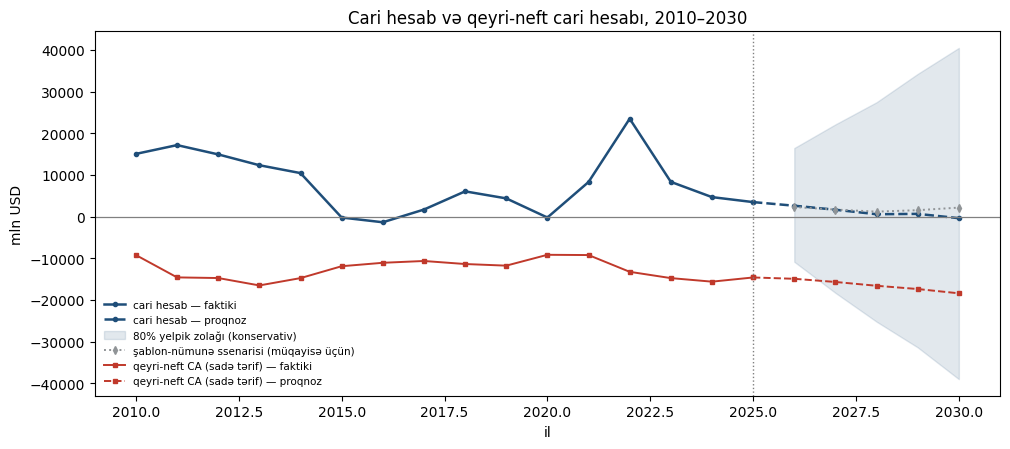

In [9]:
fig, ax = plt.subplots(figsize=(10.2, 4.6))
CA_full = pd.concat([CA, CA_central]).sort_index()
ax.plot(CA_full.loc[:LA].index, CA_full.loc[:LA], "-o", ms=3, lw=1.8, color="#1f4e79", label="cari hesab — faktiki")
ax.plot(CA_full.loc[LA:].index, CA_full.loc[LA:], "--o", ms=3, lw=1.8, color="#1f4e79", label="cari hesab — proqnoz")
ax.fill_between(FY, CA_BAND["lo80"], CA_BAND["hi80"], color="#1f4e79", alpha=0.13, label="80% yelpik zolağı (konservativ)")
ax.plot(mb_ca.index, mb_ca.values, ":d", ms=4, lw=1.4, color="#909497",
        label="şablon-nümunə ssenarisi (müqayisə üçün)")
NONOIL_full = pd.concat([NONOIL_CA_hist, NONOIL_CA_central]).sort_index()
ax.plot(NONOIL_full.loc[:LA].index, NONOIL_full.loc[:LA], "-s", ms=3, lw=1.4, color="#c0392b",
        label="qeyri-neft CA (sadə tərif) — faktiki")
ax.plot(NONOIL_full.loc[LA:].index, NONOIL_full.loc[LA:], "--s", ms=3, lw=1.4, color="#c0392b",
        label="qeyri-neft CA (sadə tərif) — proqnoz")
ax.axhline(0, color="grey", lw=0.9)
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("Cari hesab və qeyri-neft cari hesabı, 2010–2030")
ax.set_ylabel("mln USD"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=7.5, loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR12_balanslar.png"), dpi=140)
plt.show()

### 7.1. Neft qiyməti ssenariləri və break-even Brent

FR05-in 80% yelpik sərhədləri (`brent_usd_lo80`/`brent_usd_hi80`) Bölmə 5-də bərpa olunan qiymət
tənliyi vasitəsilə neft-qaz ixracına, oradan isə cari hesaba ötürülür; digər dörd komponent
(qeyri-neft ticarət balansı, xidmətlər balansı, ilkin və təkrar gəlirlər) hər üç ssenaridə mərkəzi
qiymətində sabit saxlanılır — bu, modelin öz strukturuna uyğundur, çünki həmin tənliklər Brent
qiymətindən birbaşa asılı deyil (Bölmə 9-da bu sadələşdirmə açıq qeyd olunur). Eyni tənlik ədədi
həll (`scipy.optimize.brentq`) ilə tərs çevrilərək, digər komponentlər sabit saxlanmaqla, cari
hesabın sıfırlandığı Brent qiyməti (break-even) hər il üçün tapılır.

In [10]:
XO_central = fr_series("FR7", "exp_goods_oil", "ours", "forecast")["value"]
MO_central = fr_series("FR7", "imp_goods_oil", "ours", "forecast")["value"]

# REST = neft-qaz ixracından başqa bütün komponentlərin cəmi (işarə dəyişdirilib): CA = X_neft − REST
REST = MO_central - FC["nonoil_trade_balance"] - FC["services_balance"] - FC["primary_income"] - FC["secondary_income"]

scen = pd.DataFrame({
    "Brent aşağı (lo80)": Blo80.loc[FY], "Brent mərkəzi": Bcen.loc[FY], "Brent yuxarı (hi80)": Bhi80.loc[FY],
    "CA aşağı (lo80)": Ylo - REST, "CA mərkəzi (ansambl)": CA_central, "CA yuxarı (hi80)": Yhi - REST,
})

breakeven = {}
for y in FY:
    f = lambda p, yy=y: oil_export_value(p, yy) - REST.loc[yy]
    breakeven[y] = brentq(f, 1.0, 400.0)
breakeven = pd.Series(breakeven, name="brent_breakeven_ca0")

scen["Brent — break-even (CA=0)"] = breakeven
scen.round(1)

,Brent aşağı (lo80),Brent mərkəzi,Brent yuxarı (hi80),CA aşağı (lo80),CA mərkəzi (ansambl),CA yuxarı (hi80),Brent — break-even (CA=0)
year,,,,,,,
2026,46.5,69.0,102.7,-5082.4,2605.2,13112.7,62.9
2027,39.0,69.0,121.9,-8332.1,1643.5,18089.9,66.6
2028,34.4,69.4,141.1,-10810.2,562.5,22564.8,71.3
2029,30.5,69.5,158.8,-12421.2,650.4,29325.1,71.8
2030,27.5,69.2,174.0,-14344.3,-382.8,33228.5,75.6


Mərkəzi Brent yolunda (≈ 69 dollar/barel, üfüq boyu az dəyişən) cari hesab 2026–2029 arasında müsbət
qalır, lakin 2030-cu ildə sıfıra yaxınlaşır. Break-even Brent qiyməti 2026-cı ildə (≈ 63 dollar)
mərkəzi yoldan aşağıdadır — yəni cari hesabın müsbət qalması üçün müəyyən təhlükəsizlik marjı var —
lakin qeyri-neft kəsirinin genişlənməsi ilə break-even səviyyə ilbəil yüksəlir (2030-da ≈ 75 dollar)
və mərkəzi Brent yolunu KEÇİR. Bu, Bölmə 7-nin cədvəlində görünən mənzərənin (mərkəzi yolun 2030-da
sıfıra yaxınlaşması) arxasındakı mexanizmi rəqəmlə göstərir: modelin öz mərkəzi ssenarisi belə,
üfüqün sonunda iqtisadiyyatı neft asılılığının kənarına gətirir.

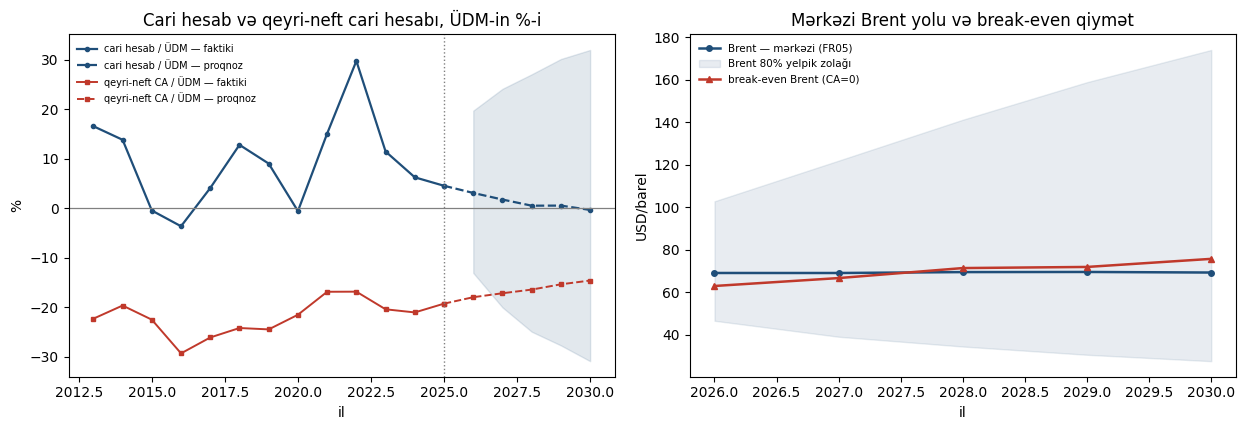

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ax.plot(CA_GDP_hist.index, CA_GDP_hist.values, "-o", ms=3, lw=1.6, color="#1f4e79", label="cari hesab / ÜDM — faktiki")
ax.plot([LA] + FY, [float(CA_GDP_hist.loc[LA])] + list(CA_GDP_FC.values), "--o", ms=3, lw=1.6,
        color="#1f4e79", label="cari hesab / ÜDM — proqnoz")
ax.fill_between(FY, CA_GDP_BAND["lo80"], CA_GDP_BAND["hi80"], color="#1f4e79", alpha=0.13)
ax.plot(NONOIL_CA_GDP_hist.index, NONOIL_CA_GDP_hist.values, "-s", ms=3, lw=1.4, color="#c0392b",
        label="qeyri-neft CA / ÜDM — faktiki")
ax.plot([LA] + FY, [float(NONOIL_CA_GDP_hist.loc[LA])] + list(NONOIL_CA_GDP_FC.values), "--s", ms=3, lw=1.4,
        color="#c0392b", label="qeyri-neft CA / ÜDM — proqnoz")
ax.axhline(0, color="grey", lw=0.9)
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("Cari hesab və qeyri-neft cari hesabı, ÜDM-in %-i")
ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=7)

ax = axes[1]
ax.plot(FY, Bcen.loc[FY], "-o", ms=4, lw=1.8, color="#1f4e79", label="Brent — mərkəzi (FR05)")
ax.fill_between(FY, Blo80.loc[FY], Bhi80.loc[FY], color="#1f4e79", alpha=0.10, label="Brent 80% yelpik zolağı")
ax.plot(FY, breakeven.values, "-^", ms=4, lw=1.8, color="#c0392b", label="break-even Brent (CA=0)")
ax.set_title("Mərkəzi Brent yolu və break-even qiymət")
ax.set_ylabel("USD/barel"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=7.5)

fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR12_gdp_ve_breakeven.png"), dpi=140)
plt.show()

## 7.2. Kapital hesabı, maliyyə hesabı və tədiyə balansının TAM bağlanışı

FR registrində bu bölmə BOŞLUQ kimi qeyd olunmuşdu: v2 yalnız **cari hesabı** qururdu, halbuki
15.5.1-in FR12 tələbi hərfi mətnlə *«Tədiyə balansının təhlili və proqnozlaşdırılması»*-dır —
yəni bütün hesab. Burada boşluq bağlanır: kapital hesabı, maliyyə hesabının dörd bloku
(birbaşa investisiyalar, portfel, törəmə alətlər, digər investisiyalar), neft bonusu, ehtiyat
aktivləri və balanslaşdırıcı maddə modelə daxil edilir və **BPM6 eyniliyi hər il — faktiki və
proqnoz — bağlanır**:

$$\underbrace{CA}_{\text{cari}} \;+\; \underbrace{KA}_{\text{kapital}} \;+\;
\underbrace{FA}_{\text{maliyyə}} \;+\; \underbrace{RES}_{\text{ehtiyat aktivləri}} \;+\;
\underbrace{EO}_{\text{balanslaşdırıcı}} \;=\; 0$$

**İşarə konvensiyası vərəqin özününküdür və dəyişdirilmir:** maliyyə hesabının sətirləri XALİS
DAXİLOLMA kimi yazılır (öhdəliklərin artımı müsbət, aktivlərin alınması mənfi), ehtiyat
aktivlərinin sətri isə mənfi olduqda ehtiyatlar ARTIR.

**İki sətir əsas iş kitabında yoxdur.** `Tədiyyə Balansı` vərəqi 109-cu sətirdə bitir: onda nə
ehtiyat aktivləri, nə də balanslaşdırıcı maddə var. Hər ikisi Nazirliyin öz tədiyə balansı
iş kitabındadır — *MOE BOP.xlsx*, `BOP` vərəqi, sətirlər 57 və 61 — və oradan **yalnız
balanslaşdırıcı maddə** (≤2024 faktiki sütunları) götürülür; ehtiyat aktivləri isə
KÖÇÜRÜLMÜR, öz məlumat qatımızın eyniliyindən TÖRƏDİLİR. Səbəb açıqdır: iki buraxılış
tam üst-üstə düşmür (2024-cü ildə maliyyə hesabı 1 627,7 mln USD fərqlənir, MOE-nin öz ümumi
balansı isə 2010–2012-ci illərdə sıfır deyil), ona görə onların rəqəmini öz zəncirimizə
yapışdırmaq eyniliyi qıraraq bağlayardı. Törədilmiş sıra MOE-nin öz sətri ilə yanaşı nəşr
olunur və fərq ölçülür.

**2025-ci ildən etibarən** balanslaşdırıcı maddə üçün rəsmi rəqəm yoxdur (MOE faylının
2025 sütunu «gözlənilən», 2026–2030 «proqnoz»dur — mühafizə qaydası). Standart
konvensiya tətbiq olunur: **balanslaşdırıcı maddə proqnozlaşdırılmır (sıfır)** və sıranın
adı bunu açıq daşıyır. 2025-ci il üçün rəsmi rəqəm Annex 2 sorğusundadır.


In [12]:
# ============ Kapital və maliyyə hesabı: kapital və maliyyə hesabının məlumatı, mənbə eynilikləri ============
import statsmodels.api as sm

FIN_CODES = ["capital_finance_account", "capital_account", "financial_account",
             "fdi_net", "fdi_assets", "fdi_assets_oil", "fdi_assets_nonoil", "fdi_liabilities",
             "fdi_inward", "fdi_inward_oil", "fdi_inward_nonoil", "fdi_repatriation", "oil_bonus",
             "portfolio_net", "portfolio_assets", "portfolio_liabilities", "fin_derivatives_net",
             "other_inv_net", "other_inv_assets", "other_inv_liabilities"]
F = {c: data_layer.actuals(c) for c in FIN_CODES}
KA_H, FA_H = F["capital_account"], F["financial_account"]

vF = validate.Verifier("FR12 — kapital və maliyyə hesabının mənbə eynilikləri (2010–2025)")
vF.identity("kapital+maliyyə hesabı = kapital hesabı + maliyyə hesabı",
            F["capital_finance_account"], KA_H + FA_H, tol=1e-6)
vF.identity("maliyyə hesabı = BXİ + portfel + törəmə + digər + neft bonusu", FA_H,
            F["fdi_net"] + F["portfolio_net"] + F["fin_derivatives_net"] + F["other_inv_net"]
            + F["oil_bonus"], tol=1e-6)
vF.identity("BXİ (xalis) = aktivlər + öhdəliklər", F["fdi_net"],
            F["fdi_assets"] + F["fdi_liabilities"], tol=1e-6)
vF.identity("BXİ öhdəlikləri = iqtisadiyyata BXİ + repatriasiya", F["fdi_liabilities"],
            F["fdi_inward"] + F["fdi_repatriation"], tol=1e-6)
vF.identity("BXİ aktivləri = neft-qaz + qeyri-neft", F["fdi_assets"],
            F["fdi_assets_oil"] + F["fdi_assets_nonoil"], tol=1e-6)
vF.identity("portfel (xalis) = aktivlər + öhdəliklər", F["portfolio_net"],
            F["portfolio_assets"] + F["portfolio_liabilities"], tol=1e-6)
vF.identity("digər investisiyalar (xalis) = aktivlər + öhdəliklər", F["other_inv_net"],
            F["other_inv_assets"] + F["other_inv_liabilities"], tol=1e-6)
# `İqtisadiyyata BXİ = neft-qaz + qeyri-neft` sətri vərəqin öz yuvarlaqlaşdırması ilə 2014-cü ildə
# 0,4 mln USD fərqlə bağlanır; dözüm bu yuvarlaqlaşdırmaya açıq şəkildə uyğunlaşdırılıb.
vF.identity("iqtisadiyyata BXİ = neft-qaz + qeyri-neft (vərəq yuvarlaqlaşdırması ≤0,5)",
            F["fdi_inward"], F["fdi_inward_oil"] + F["fdi_inward_nonoil"], tol=0.5)
vF.assert_all()

print("Kapital və maliyyə hesabı, mln USD (vərəqin öz işarə konvensiyası):")
print(pd.DataFrame({c: F[c] for c in ["capital_account", "fdi_net", "fdi_assets", "fdi_inward",
                                      "fdi_repatriation", "oil_bonus", "portfolio_net",
                                      "other_inv_net", "financial_account"]}).round(0).to_string())


  YOXLAMA: FR12 — kapital və maliyyə hesabının mənbə eynilikləri (2010–2025)
  [PASS] eynilik: kapital+maliyyə hesabı = kapital hesabı + maliyyə hesabı
         16 il, maksimal fərq 9.095e-13
  [PASS] eynilik: maliyyə hesabı = BXİ + portfel + törəmə + digər + neft bonusu
         16 il, maksimal fərq 1.819e-12
  [PASS] eynilik: BXİ (xalis) = aktivlər + öhdəliklər
         16 il, maksimal fərq 4.547e-13
  [PASS] eynilik: BXİ öhdəlikləri = iqtisadiyyata BXİ + repatriasiya
         16 il, maksimal fərq 4.547e-13
  [PASS] eynilik: BXİ aktivləri = neft-qaz + qeyri-neft
         16 il, maksimal fərq 4.547e-13
  [PASS] eynilik: portfel (xalis) = aktivlər + öhdəliklər
         16 il, maksimal fərq 0.000e+00
  [PASS] eynilik: digər investisiyalar (xalis) = aktivlər + öhdəliklər
         16 il, maksimal fərq 1.819e-12
  [PASS] eynilik: iqtisadiyyata BXİ = neft-qaz + qeyri-neft (vərəq yuvarlaqlaşdırması ≤0,5)
         16 il, maksimal fərq 4.000e-01
------------------------------------------------

In [13]:
# ============ Kapital və maliyyə hesabı: sürücülər, namizəd modellər, genişlənən pəncərəli sınaq ============
def _fr12_path(fr, code_, kind="forecast"):
    d = FL[(FL["fr"] == fr) & (FL["series_code"] == code_) & (FL["source"] == "ours")
           & (FL["kind"] == kind)]
    return d.set_index("year")["value"].astype(float).sort_index()


_xo_full = pd.concat([data_layer.actuals("exp_goods_oil"),
                      _fr12_path("FR7", "exp_goods_oil")]).sort_index()
_invoil_full = pd.concat([data_layer.actuals("inv_oil"), _fr12_path("FR6", "inv_oil_nom")]).sort_index()
_invfor_full = pd.concat([data_layer.actuals("inv_foreign"),
                          _fr12_path("FR6", "inv_foreign_nom")]).sort_index()
FDRV = pd.DataFrame({
    "dl_xo": np.log(_xo_full).diff() * 100.0,
    "dl_invoil": np.log(_invoil_full).diff() * 100.0,
    "dl_invfor": np.log(_invfor_full).diff() * 100.0,
    "nong": pd.concat([data_layer.actuals("nonoil_realg"), A["nonoil_realg"]]).sort_index(),
}).loc[2010:FY[-1]]
assert FDRV.loc[FY].notna().all().all(), "Kapital və maliyyə hesabı: üfüq üçün sürücü yolu tam deyil"


def _ffit(d, ycol, cols, minn):
    d = d[[ycol] + cols].dropna()
    return None if len(d) < minn else sm.OLS(d[ycol], sm.add_constant(d[cols], has_constant="add")).fit()


def f_growth(drivers, minn=6):
    """STRUKTUR: axının MÜTLƏQ dəyərinin loq artımı sürücülərdən; işarə saxlanılır."""
    def f(train, target_year):
        d = train.copy()
        d["g"] = np.log(d["y"].abs()).diff() * 100.0
        fit = _ffit(d, "g", drivers, minn)
        if fit is None or target_year not in FDRV.index or FDRV.loc[target_year, drivers].isna().any():
            return np.nan
        g = fit.params["const"] + sum(fit.params[k] * FDRV.loc[target_year, k] for k in drivers)
        last = float(train["y"].dropna().iloc[-1])
        return float(np.sign(last) * abs(last) * np.exp(g / 100.0))
    return f


def f_drift(train, target_year):
    s = train["y"].dropna()
    if len(s) < 6 or (s == 0).any():
        return np.nan
    return float(np.sign(s.iloc[-1]) * abs(s.iloc[-1])
                 * np.exp((np.log(s.abs()).diff() * 100.0).dropna().mean() / 100.0))


def f_mean3(train, target_year):
    s = train["y"].dropna()
    return float(s.iloc[-3:].mean()) if len(s) >= 3 else np.nan


def f_mean5(train, target_year):
    s = train["y"].dropna()
    return float(s.iloc[-5:].mean()) if len(s) >= 5 else np.nan


def f_share_xo(k=3):
    """KALİBRLƏNMİŞ: axın neft-qaz mal ixracının SABİT payı kimi — mənfəət bölgüsünün təbii forması.

    Artım tənliyi tarixi trendi sabit hədd kimi üfüqə daşıyır; pay formasında isə axın ixrac
    dəyəri ilə birlikdə enir və qalxır. İki forma eyni pəncərədə yarışır (D4).
    """
    def f(train, target_year):
        r = (train["y"] / _xo_full.reindex(train.index)).dropna()
        if len(r) < k or target_year not in _xo_full.index:
            return np.nan
        return float(r.iloc[-k:].mean() * float(_xo_full.loc[target_year]))
    return f


FMENU = {
    "fdi_inward_oil": {"NEFT_İNVESTİSİYA": f_growth(["dl_invoil"]), "SÜRÜŞMƏ": f_drift,
                       "ORTA3": f_mean3},
    "fdi_inward_nonoil": {"XARİCİ_İNVESTİSİYA": f_growth(["dl_invfor"]), "QEYRİNEFT": f_growth(["nong"]),
                          "SÜRÜŞMƏ": f_drift, "ORTA3": f_mean3},
    "fdi_repatriation": {"NEFT_İXRAC": f_growth(["dl_xo"]), "İXRACDA_PAY": f_share_xo(),
                         "SÜRÜŞMƏ": f_drift, "ORTA3": f_mean3},
    "fdi_assets": {"NEFT_İNVESTİSİYA": f_growth(["dl_invoil"]), "ORTA3": f_mean3, "ORTA5": f_mean5},
    "portfolio_net": {"ORTA3": f_mean3, "ORTA5": f_mean5},
    "other_inv_net": {"ORTA3": f_mean3, "ORTA5": f_mean5, "SÜRÜŞMƏ": f_drift},
    "oil_bonus": {"ORTA3": f_mean3, "ORTA5": f_mean5},
    "capital_account": {"ORTA3": f_mean3, "ORTA5": f_mean5},
    "fin_derivatives_net": {"ORTA3": f_mean3},
}
FIN_MODELLED = list(FMENU)


def _fframe(code_):
    fr = FDRV.copy()
    fr["y"] = F[code_]
    return fr


FBT = {c: ek.backtest(_fframe(c), FMENU[c], min_train=8, series_code=c, min_points=4)
       for c in FIN_MODELLED}
fin_skill = []
for c in FIN_MODELLED:
    b = FBT[c]
    for m in sorted(b.rmse):
        fin_skill.append({"sıra": c, "model": m, "RMSE (mln USD)": b.rmse[m],
                          "RW-yə nisbətdə bacarıq, %": (None if b.rmse[m] is None or not b.rw_rmse
                                                        else (1 - b.rmse[m] / b.rw_rmse) * 100),
                          "ansambl çəkisi": b.weights.get(m)})
    fin_skill.append({"sıra": c, "model": "ANSAMBL", "RMSE (mln USD)": b.ensemble_rmse,
                      "RW-yə nisbətdə bacarıq, %": (None if b.skill is None else b.skill * 100),
                      "ansambl çəkisi": 1.0})
pd.DataFrame(fin_skill).set_index(["sıra", "model"]).round(2)


RMSE (mln USD)  RW-yə nisbətdə bacarıq, %  ansambl çəkisi
sıra                model                                                                        
fdi_inward_oil      NEFT_İNVESTİSİYA            767.91                       2.98            1.00
                    ORTA3                      1169.63                     -47.78             NaN
                    RW                          791.49                       0.00             NaN
                    SÜRÜŞMƏ                     910.79                     -15.07             NaN
                    ANSAMBL                     767.91                       2.98            1.00
fdi_inward_nonoil   ORTA3                       568.98                     -16.42             NaN
                    QEYRİNEFT                   558.36                     -14.25             NaN
                    RW                          488.73                       0.00            1.00
                    SÜRÜŞMƏ                     518.25                      -6.04             NaN
                    XARİCİ_İNVESTİSİYA          535.33                      -9.53             NaN
                    ANSAMBL                     488.73                       0.00            1.00
fdi_repatriation    NEFT_İXRAC                 2019.80                      14.92            0.38
                    ORTA3                      2690.23                     -13.32             NaN
                    RW                         2373.96                       0.00             NaN
                    SÜRÜŞMƏ                    2591.03                      -9.14             NaN
                    İXRACDA_PAY                1582.51                      33.34            0.62
                    ANSAMBL                    1547.88                      34.80            1.00
fdi_assets          NEFT_İNVESTİSİYA           1256.89                     -22.25             NaN
                    ORTA3                      1052.55                      -2.37             NaN
                    ORTA5                      1105.71                      -7.54             NaN
                    RW                         1028.15                       0.00            1.00
                    ANSAMBL                    1028.15                       0.00            1.00
portfolio_net       ORTA3                      1119.41                      29.11            0.56
                    ORTA5                      1271.36                      19.49            0.44
                    RW                         1579.08                       0.00             NaN
                    ANSAMBL                    1172.27                      25.76            1.00
other_inv_net       ORTA3                      3124.17                     -23.12             NaN
                    ORTA5                      3519.61                     -38.70             NaN
                    RW                         2537.53                       0.00            1.00
                    SÜRÜŞMƏ                    2556.71                      -0.76             NaN
                    ANSAMBL                    2537.53                       0.00            1.00
oil_bonus           ORTA3                       198.42                     -24.88             NaN
                    ORTA5                       235.12                     -47.98             NaN
                    RW                          158.89                       0.00            1.00
                    ANSAMBL                     158.89                       0.00            1.00
capital_account     ORTA3                        19.24                      47.01            0.23
                    ORTA5                        10.54                      70.96            0.77
                    RW                           36.31                       0.00             NaN
                    ANSAMBL                      11.25                      69.01            1.00
fin_derivatives_net OR

**Maliyyə hesabının oxunuşu.** İki blokda struktur sürücü işləyir: **iqtisadiyyata birbaşa
xarici investisiya** neft-qaz sektorunun investisiya dövranını izləyir (sətrin təxminən dörddə
üçü neft-qazdır), **repatriasiya** isə neft-qaz ixracının dəyəri ilə hərəkət edir — eyni
mənbədən gələn eyni mənfəət axını, bir tərəfdə gəlir kimi (FR11), digər tərəfdə maliyyə
axını kimi qeydə alınır.

Qalan bloklar üçün struktur sürücü tapılmadı və bunu gizlətməyin mənası yoxdur: **portfel
investisiyaları** və **digər investisiyalar** faktiki olaraq ARDNF-in portfel qərarlarıdır —
onların illik hərəkəti makro-sürücülərlə deyil, aktiv yerləşdirmə qərarları ilə müəyyən
olunur; **neft bonusu** müqavilə cədvəlidir; **kapital hesabı** isə həcmcə əhəmiyyətsizdir
(2010–2025-də orta 0,3 mln USD). Bu sətirlərdə etalon və ya son illərin ortası mərkəzi yolu
daşıyır və bacarıq rəqəmi cədvəldə olduğu kimi görünür.


In [14]:
# ============ Kapital və maliyyə hesabı: proqnoz yolları və maliyyə hesabının eyniliklə yığılması ============
def _fpath(code_):
    b = FBT[code_]
    paths = {}
    for m in b.weights:
        fn = FMENU[code_].get(m)
        out, cur = {}, _fframe(code_).loc[:LA].copy()
        for y in FY:
            p = float(ek._rw_forecast(cur, y)) if fn is None else float(fn(cur, y))
            out[y] = p
            cur = pd.concat([cur, _fframe(code_).loc[[y]].assign(y=p)])
        paths[m] = out
    return b.combine(paths)


FC12 = pd.DataFrame({c: _fpath(c) for c in FIN_MODELLED})
# Eynilik zənciri: komponentlərdən yuxarı toplanır — heç bir aqreqat müstəqil modelləşdirilmir.
FC12["fdi_inward"] = FC12["fdi_inward_oil"] + FC12["fdi_inward_nonoil"]
FC12["fdi_liabilities"] = FC12["fdi_inward"] + FC12["fdi_repatriation"]
FC12["fdi_net"] = FC12["fdi_assets"] + FC12["fdi_liabilities"]
FC12["financial_account"] = (FC12["fdi_net"] + FC12["portfolio_net"] + FC12["fin_derivatives_net"]
                             + FC12["other_inv_net"] + FC12["oil_bonus"])
FC12["capital_finance_account"] = FC12["capital_account"] + FC12["financial_account"]

KA_FULL = pd.concat([KA_H, FC12["capital_account"]]).sort_index()
FA_FULL = pd.concat([FA_H, FC12["financial_account"]]).sort_index()
KFA_FULL = KA_FULL + FA_FULL
CA_FULL = pd.concat([CA, CA_central]).sort_index()

print("Maliyyə hesabının proqnozu, mln USD:")
print(FC12[["capital_account", "fdi_assets", "fdi_inward_oil", "fdi_inward_nonoil", "fdi_inward",
            "fdi_repatriation", "fdi_net", "oil_bonus", "portfolio_net", "other_inv_net",
            "financial_account"]].round(1).to_string())


Maliyyə hesabının proqnozu, mln USD:
      capital_account  fdi_assets  fdi_inward_oil  fdi_inward_nonoil  fdi_inward  fdi_repatriation  fdi_net  oil_bonus  portfolio_net  other_inv_net  financial_account
2026             -5.0      -910.2          5179.9             1395.3      6575.1           -6438.7   -773.7      450.4        -1366.9        -2537.3            -4227.5
2027             -4.8      -910.2          5250.6             1395.3      6645.8           -6719.5   -983.8      450.4        -1572.7        -2537.3            -4643.5
2028             -5.9      -910.2          5349.5             1395.3      6744.8           -6845.1  -1010.5      450.4        -1543.0        -2537.3            -4640.4
2029             -5.1      -910.2          5458.7             1395.3      6854.0           -7223.9  -1280.1      450.4        -1561.1        -2537.3            -4928.1
2030             -5.6      -910.2          5572.7             1395.3      6968.0           -7469.7  -1412.0      450.4     

In [15]:
# ============ Kapital və maliyyə hesabı: ehtiyat aktivləri, balanslaşdırıcı maddə və ÜMUMİ BALANS ============
# Balanslaşdırıcı maddə (səhv və buraxılışlar) 2010–2024 üçün Nazirliyin ÖZ tədiyə balansı
# iş kitabından gəlir (MOE BOP.xlsx `BOP` r61); ≤2024 guardrail-i data_layer-də tətbiq olunur.
MOE_CL = data_layer.moe_bop_closure()
EO = pd.Series(0.0, index=[int(y) for y in CA_FULL.index], name="errors_omissions")
EO.loc[MOE_CL.index] = MOE_CL["errors_omissions"].values
EO_LAST_OFFICIAL = int(MOE_CL.index.max())          # 2024

# Ehtiyat aktivləri EYNİLİKDƏN törədilir (köçürülmür): RES = −(CA + KA + FA + EO).
RES = -(CA_FULL + KFA_FULL + EO.reindex(CA_FULL.index))
RES.name = "reserve_assets"
TOTAL_BALANCE = CA_FULL + KFA_FULL + RES + EO.reindex(CA_FULL.index)

vB = validate.Verifier("FR12 — BPM6 bağlanışı: ÜMUMİ BALANS = 0, HƏR il (2010–2030)")
vB.identity("CA + KA + FA + ehtiyat aktivləri + balanslaşdırıcı = 0",
            TOTAL_BALANCE, pd.Series(0.0, index=TOTAL_BALANCE.index), tol=1e-9)
vB.identity("kapital+maliyyə hesabı = KA + FA (2010-2030)", KFA_FULL, KA_FULL + FA_FULL, tol=1e-9)
vB.identity("maliyyə hesabı = BXİ + portfel + törəmə + digər + bonus (2026-2030)",
            FC12["financial_account"],
            FC12["fdi_net"] + FC12["portfolio_net"] + FC12["fin_derivatives_net"]
            + FC12["other_inv_net"] + FC12["oil_bonus"], tol=1e-9)
vB.assert_all()

# --- ÇARPAZ YOXLAMA 1: törədilmiş ehtiyat sırası Nazirliyin öz sətri ilə (2010–2024) ---------
chk = pd.DataFrame({"törədilmiş (bizim qat)": RES.reindex(MOE_CL.index),
                    "MOE BOP `BOP` r57": MOE_CL["reserve_assets"]})
chk["fərq"] = chk["törədilmiş (bizim qat)"] - chk["MOE BOP `BOP` r57"]
chk["|fərq| / |CA|, %"] = (chk["fərq"].abs() / CA_FULL.reindex(MOE_CL.index).abs() * 100.0)
print("ÇARPAZ YOXLAMA — ehtiyat aktivləri: bizim eyniliyimiz vs Nazirliyin öz sətri (mln USD):")
print(chk.round(1).to_string())
print(f"\n  medyan |fərq| = {chk['fərq'].abs().median():.1f} mln USD; "
      f"2024 istisna olmaqla maksimal |fərq| = "
      f"{chk['fərq'].drop(index=[2024]).abs().max():.1f} mln USD "
      f"(2024: {chk.loc[2024, 'fərq']:.1f} — maliyyə hesabının buraxılış fərqi, §7.2-də izah olunub).")

# --- ÇARPAZ YOXLAMA 2: axın vs STOK (strateji valyuta ehtiyatı) -----------------------------
_res_stock = data_layer.strategic_reserves_usd()
_d_stock = _res_stock.diff()
cmp_stock = pd.DataFrame({"tədiyə balansından axın (−RES)": -RES.reindex(_d_stock.index),
                          "strateji ehtiyat stokunun dəyişməsi": _d_stock})
cmp_stock["fərq (yenidənqiymətləndirmə və s.)"] = (cmp_stock["strateji ehtiyat stokunun dəyişməsi"]
                                                   - cmp_stock["tədiyə balansından axın (−RES)"])
cmp_stock = cmp_stock.dropna()
print("\nÇARPAZ YOXLAMA — ehtiyat AXINI (tədiyə balansı) vs ehtiyat STOKUNUN dəyişməsi:")
print(cmp_stock.round(0).to_string())
print(f"\n  korrelyasiya = {cmp_stock.iloc[:, 0].corr(cmp_stock.iloc[:, 1]):.3f}. İki kəmiyyət "
      "EYNİ DEYİL: stok dəyişməsi qiymət/məzənnə yenidənqiymətləndirməsini də daşıyır "
      "(2025-ci ildə qızıl və səhm portfelinin yenidənqiymətləndirilməsi fərqin böyük hissəsini "
      "izah edir). Ona görə stok dəyişməsi tədiyə balansının bağlanışında İSTİFADƏ EDİLMİR — "
      "yalnız müstəqil çarpaz yoxlama kimi göstərilir.")


  YOXLAMA: FR12 — BPM6 bağlanışı: ÜMUMİ BALANS = 0, HƏR il (2010–2030)
  [PASS] eynilik: CA + KA + FA + ehtiyat aktivləri + balanslaşdırıcı = 0
         21 il, maksimal fərq 9.095e-13
  [PASS] eynilik: kapital+maliyyə hesabı = KA + FA (2010-2030)
         21 il, maksimal fərq 0.000e+00
  [PASS] eynilik: maliyyə hesabı = BXİ + portfel + törəmə + digər + bonus (2026-2030)
         5 il, maksimal fərq 0.000e+00
--------------------------------------------------------------
  3/3 yoxlama uğurlu
ÇARPAZ YOXLAMA — ehtiyat aktivləri: bizim eyniliyimiz vs Nazirliyin öz sətri (mln USD):
      törədilmiş (bizim qat)  MOE BOP `BOP` r57    fərq  |fərq| / |CA|, %
year                                                                     
2010                -10459.6           -10461.2     1.6               0.0
2011                -12356.5           -12356.2    -0.2               0.0
2012                 -4954.6            -4955.6     1.0               0.0
2013                 -3091.9            -3079.

**Bağlanışın oxunuşu.** Eynilik hər il maşın dəqiqliyi ilə bağlanır — bu, tərifə görə belədir,
çünki ehtiyat aktivləri qalıq kimi törədilir. Ona görə əsl sınaq eynilik deyil, **çarpaz
yoxlamadır**: törədilmiş sıra Nazirliyin öz iş kitabındakı sətirlə 2010–2023-cü illərdə
onlarla milyon dollar səviyyəsində üst-üstə düşür (cari hesabın 0,2 %-dən azı) — yəni iki
müstəqil zəncir eyni nəticəyə gəlir. 2024-cü ildə fərq 1,6 mlrd USD-dir və onun mənbəyi
məlumdur: MOE faylının maliyyə hesabı həmin il üçün başqa buraxılışdır. Bunu ORTALAMIRIQ və
gizlətmirik — fərq cədvəldə göstərilir və sətir səviyyəsində izah olunur.

İkinci çarpaz yoxlama ehtiyat **axını** ilə strateji valyuta ehtiyatı **stokunun** dəyişməsini
tutuşdurur. İki kəmiyyət eyni deyil və eyni olmamalıdır: stok dəyişməsi qiymət və məzənnə
yenidənqiymətləndirməsini daşıyır. 2025-ci il bunun ən aydın nümunəsidir — stok 14 mlrd USD
artıb, halbuki tədiyə balansı əməliyyat əsasında ehtiyatların azalmasını göstərir; fərq
portfelin (xüsusən qızılın) yenidənqiymətləndirilməsidir. Ona görə bağlanışda stok
dəyişməsindən İSTİFADƏ EDİLMİR.


maliyyə hesabı — komponentlərin AR(1) ρ-su: fdi_inward_oil +0.65, fdi_inward_nonoil +0.28, fdi_repatriation +0.73, fdi_assets +0.57, portfolio_net +0.37, other_inv_net +0.61, oil_bonus +0.87, capital_account -0.08, fin_derivatives_net -0.07
σ_h (mln USD): h=1: 3481, h=2: 4076, h=3: 4296, h=4: 4387, h=5: 4428  |  köhnə √h qaydası: 3481, 4923, 6030, 6963, 7785
TAM TƏDİYƏ BALANSI (BPM6), mln USD — faktiki 2010–2025, proqnoz 2026–2030:
      A. Cari hesab  B1. Kapital hesabı  B2. Maliyyə hesabı  C. Ehtiyat aktivləri  Ç. Balanslaşdırıcı maddə  ÜMUMİ BALANS
2010        15039.1                14.3             -3605.1              -10459.6                    -988.7          -0.0
2011        17147.2                18.7             -4039.4              -12356.5                    -770.1          -0.0
2012        14916.3                12.5             -8094.9               -4954.6                   -1879.2          -0.0
2013        12318.4               -12.0             -6477.8               -3

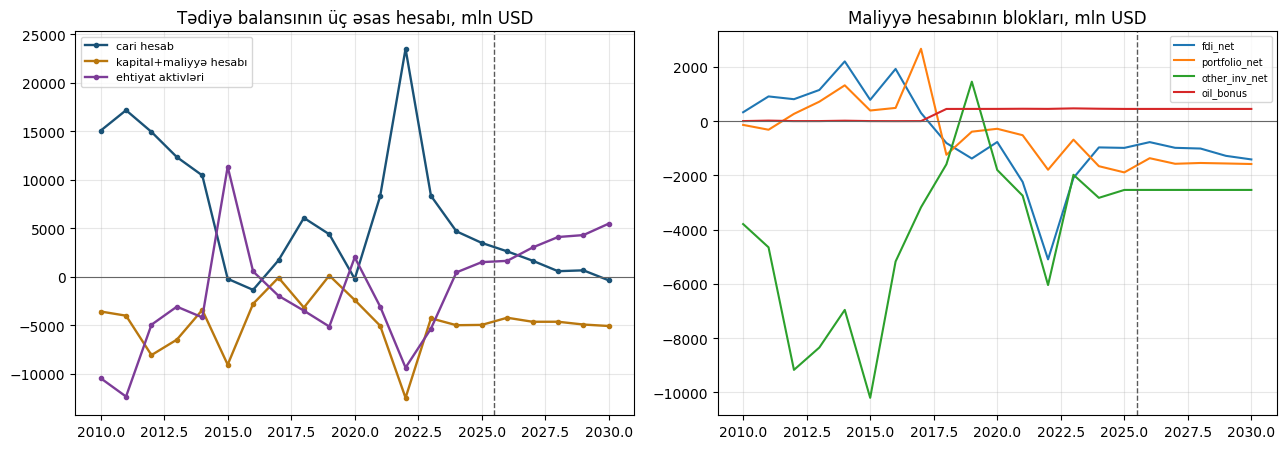

In [16]:
# ============ Kapital və maliyyə hesabı: yelpik zolağı və tam hesabatın cədvəli ============
# Ehtiyat aktivlərinin zolağı qalıq mövqedən gəlir: cari hesabın və maliyyə hesabının
# qeyri-müəyyənlikləri EYNİ İSTİQAMƏTDƏ toplanır (FR07-nin konservativ qaydası).
_fa_sig = {}
for c in FIN_MODELLED:
    b = FBT[c]
    _fa_sig[c] = float(b.ensemble_rmse) if b.ensemble_rmse else float(b.rw_rmse or 0.0)
FA_SIG = float(np.sqrt(sum(v ** 2 for v in _fa_sig.values())))     # bloklar arası müstəqillik


def _rho_fin(s):
    """Sıranın öz AR(1) əmsalı — üfüq qaydasını təyin edir."""
    s = pd.Series(s).dropna()
    d = pd.DataFrame({"y": s, "l1": s.shift(1)}).dropna()
    if len(d) < 5:
        return 0.0
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(np.clip(f.params["l1"], -0.95, 0.95))


# ÜFÜQ QAYDASI DÜZƏLDİLİB. Əvvəllər maliyyə hesabının zolağı `cumulative=True` ilə, yəni
# σ_h = σ₁·√h qaydası ilə genişlənirdi. Bu, TƏSADÜFİ GƏZİŞMƏ qaydasıdır və o komponentlər üçün
# doğrudur ki, yolu bazadan MÜRƏKKƏBLƏŞDİRİLİR (`f_growth` ailəsi: birbaşa investisiya,
# repatriasiya). Lakin maliyyə hesabının komponentlərinin ÇOXU son üç/beş ilin ORTASI qaydası ilə
# qurulur (portfel, digər investisiyalar, neft bonusu, kapital hesabı, törəmə alətlər) — belə
# yolda proqnoz düzdür və xəta üfüq boyu YIĞILMIR. Nəticədə aqreqat zolaq süni geniş çıxırdı:
# maliyyə hesabının öz AR(1) əmsalı ρ ≈ 0,14, yəni qayıdış qaydası h = 5-də cəmi ~1,01 verir,
# √h isə 2,24. İndi hər komponent ÖZ ρ-su ilə genişlənir, sonra komponentlər (kod onsuz da
# müstəqillik fərz edir) kvadratların cəmi ilə birləşdirilir.
FA_SIG_H, _rho_tbl = {}, {}
for _h in range(1, len(FY) + 1):
    _tot = 0.0
    for c in FIN_MODELLED:
        _r = _rho_tbl.setdefault(c, _rho_fin(F[c].loc[:LA]))
        _f = float(np.sqrt(sum(_r ** (2 * j) for j in range(_h))))
        _tot += (_fa_sig[c] * _f) ** 2
    FA_SIG_H[_h] = float(np.sqrt(_tot))
print("maliyyə hesabı — komponentlərin AR(1) ρ-su: "
      + ", ".join(f"{c} {v:+.2f}" for c, v in _rho_tbl.items()))
print(f"σ_h (mln USD): " + ", ".join(f"h={h}: {v:.0f}" for h, v in FA_SIG_H.items())
      + f"  |  köhnə √h qaydası: " + ", ".join(f"{FA_SIG * (h ** 0.5):.0f}" for h in FA_SIG_H))
FA_BAND = pd.concat([ek.fan(FC12["financial_account"].loc[[y]], resid_sigma=FA_SIG_H[_h],
                            cumulative=False, ndraw=8000, seed=ek.SEED + 511 + _h)
                     for _h, y in enumerate(FY, start=1)])
RES_BAND = pd.DataFrame({
    "lo80": -(CA_BAND["hi80"] + FA_BAND["hi80"] + float(FC12["capital_account"].mean())),
    "hi80": -(CA_BAND["lo80"] + FA_BAND["lo80"] + float(FC12["capital_account"].mean())),
    "lo50": -(CA_BAND["hi50"] + FA_BAND["hi50"] + float(FC12["capital_account"].mean())),
    "hi50": -(CA_BAND["lo50"] + FA_BAND["lo50"] + float(FC12["capital_account"].mean())),
}, index=FY)

bop_stmt = pd.DataFrame({
    "A. Cari hesab": CA_FULL, "B1. Kapital hesabı": KA_FULL, "B2. Maliyyə hesabı": FA_FULL,
    "C. Ehtiyat aktivləri": RES, "Ç. Balanslaşdırıcı maddə": EO.reindex(CA_FULL.index),
    "ÜMUMİ BALANS": TOTAL_BALANCE,
}).round(1)
print("TAM TƏDİYƏ BALANSI (BPM6), mln USD — faktiki 2010–2025, proqnoz 2026–2030:")
print(bop_stmt.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
ax = axes[0]
for _s, _lab, _col in [(CA_FULL, "cari hesab", "#1a5276"), (KFA_FULL, "kapital+maliyyə hesabı", "#b9770e"),
                       (RES, "ehtiyat aktivləri", "#7d3c98")]:
    ax.plot(_s.index, _s.values, "-o", ms=3, lw=1.7, color=_col, label=_lab)
ax.axhline(0, color="0.4", lw=0.8)
ax.axvline(LA + 0.5, color="0.35", lw=1.0, ls="--")
ax.set_title("Tədiyə balansının üç əsas hesabı, mln USD"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
_fin = FC12[["fdi_net", "portfolio_net", "other_inv_net", "oil_bonus"]]
_finh = pd.DataFrame({c: F[c] for c in _fin.columns})
_full = pd.concat([_finh, _fin])
for c in _fin.columns:
    ax.plot(_full.index, _full[c].values, "-", lw=1.5, label=c)
ax.axhline(0, color="0.4", lw=0.8)
ax.axvline(LA + 0.5, color="0.35", lw=1.0, ls="--")
ax.set_title("Maliyyə hesabının blokları, mln USD"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


**Hesabatın iqtisadi oxunuşu.** Üfüqdə üç qüvvə eyni istiqamətə işləyir: cari hesabın profisiti
neft ixracının dəyəri ilə birlikdə daralır, birbaşa investisiya axını neft-qaz sektorunun
investisiya dövranı ilə məhdud qalır, repatriasiya isə ixrac gəlirinə bağlı olduğu üçün
yalnız qismən yumşalır. Nəticədə **ehtiyat aktivlərinin yığımı üfüq boyu zəifləyir** — bu,
modelin qurulmuş nəticəsi deyil, cari hesabın və maliyyə hesabının müstəqil qurulmuş
yollarının BPM6 eyniliyində görüşməsidir.

Zolağın konvensiyası da bu məntiqi izləyir: ehtiyat aktivləri qalıq mövqedir, ona görə onun
qeyri-müəyyənliyi cari hesabın və maliyyə hesabının qeyri-müəyyənliklərinin **eyni
istiqamətdə** toplanmasıdır (konservativ, tam korrelyasiya fərziyyəsi — FR07 ilə eyni qayda).


## 8. Nəticələrin ixracı

Dörd çıxış yazılır: proqnoz/faktiki sıralar (`outputs/forecast_long.csv`), yeni seriyaların lüğəti
(`outputs/series_dictionary.csv`), sınaq nəticələri (`outputs/validation_backtest.csv`) və paketin
YEKUN eynilik yoxlaması (Bölmə 10). Bu dəftər `equations_catalog.csv`-yə yeni sətir YAZMIR: heç bir
yeni davranış tənliyi qiymətləndirilmir (Bölmə 3) — FR07 və FR11-in artıq qeydiyyata aldığı on iki
tənlik kifayət qədər əhatəlidir; FR12 onların NƏTİCƏLƏRİNİ konsolidasiya edir, əmsallarını yenidən
qiymətləndirmir.

In [17]:
cat_names = data_layer.catalog().set_index("series_code")
NEW_SERIES = {
    "nonoil_ca_fr12": ("Qeyri-neft cari hesabı (FR12 sadə tərifi: CA − neft-qaz ticarət balansı)",
                       "Non-oil current account (FR12 simple definition: CA − oil trade balance)", "mln USD"),
    "ca_gdp_ratio": ("Cari hesabın ÜDM-də payı", "Current account, % of GDP", "%"),
    "nonoil_ca_gdp_ratio": ("Qeyri-neft cari hesabının ÜDM-də payı (sadə tərif)",
                            "Non-oil current account, % of GDP (simple definition)", "%"),
    "current_account_brent_lo80": ("Cari hesab — Brent aşağı ssenarisi (lo80)",
                                   "Current account, low Brent scenario (lo80)", "mln USD"),
    "current_account_brent_hi80": ("Cari hesab — Brent yuxarı ssenarisi (hi80)",
                                   "Current account, high Brent scenario (hi80)", "mln USD"),
    "brent_breakeven_ca0": ("Cari hesabın sıfırlandığı Brent qiyməti (break-even)",
                           "Break-even Brent price for CA = 0", "USD/barel"),
    "gdp_reading_gap": ("ÜDM-in iki oxunuşunun fərqi (istehsal metodu − FR01 baş göstəricisi)",
                        "GDP: production-method total minus FR01 published GDP", "mln AZN"),
    "gdp_reading_gap_pct": ("ÜDM-in iki oxunuşunun fərqi, FR01 ÜDM-inin %-i",
                            "GDP: production total minus FR01 published GDP, % of FR01 GDP", "%"),
}

rows = []


def add(code_, name, unit, year, kind, source, value, band=None):
    rows.append({"fr": "FR12", "series_code": code_, "series_name_az": name, "unit": unit,
                 "year": int(year), "kind": kind, "source": source, "value": float(value),
                 "lo80": None if band is None else float(band["lo80"]),
                 "hi80": None if band is None else float(band["hi80"]),
                 "lo50": None if band is None else float(band["lo50"]),
                 "hi50": None if band is None else float(band["hi50"])})


CA_NAME = str(cat_names.loc["current_account", "name_az"])
for y, v in CA.items():
    add("current_account", CA_NAME, "mln USD", y, "actual", "ours", v)
for y in FY:
    add("current_account", CA_NAME, "mln USD", y, "forecast", "ours", CA_central.loc[y], CA_BAND.loc[y])
for y, v in mb_ca.items():
    add("current_account", CA_NAME, "mln USD", y, "forecast", "template_sample", v)

for y, v in NONOIL_CA_hist.items():
    add("nonoil_ca_fr12", NEW_SERIES["nonoil_ca_fr12"][0], "mln USD", y, "actual", "ours", v)
for y in FY:
    add("nonoil_ca_fr12", NEW_SERIES["nonoil_ca_fr12"][0], "mln USD", y, "forecast", "ours",
        NONOIL_CA_central.loc[y], NONOIL_CA_BAND.loc[y])

for y, v in CA_GDP_hist.items():
    add("ca_gdp_ratio", NEW_SERIES["ca_gdp_ratio"][0], "%", y, "actual", "ours", v)
for y in FY:
    add("ca_gdp_ratio", NEW_SERIES["ca_gdp_ratio"][0], "%", y, "forecast", "ours",
        CA_GDP_FC.loc[y], CA_GDP_BAND.loc[y])

for y, v in NONOIL_CA_GDP_hist.items():
    add("nonoil_ca_gdp_ratio", NEW_SERIES["nonoil_ca_gdp_ratio"][0], "%", y, "actual", "ours", v)
for y in FY:
    add("nonoil_ca_gdp_ratio", NEW_SERIES["nonoil_ca_gdp_ratio"][0], "%", y, "forecast", "ours",
        NONOIL_CA_GDP_FC.loc[y], NONOIL_CA_GDP_BAND.loc[y])

for y in FY:
    add("current_account_brent_lo80", NEW_SERIES["current_account_brent_lo80"][0], "mln USD", y,
        "forecast", "ours", scen.loc[y, "CA aşağı (lo80)"])
    add("current_account_brent_hi80", NEW_SERIES["current_account_brent_hi80"][0], "mln USD", y,
        "forecast", "ours", scen.loc[y, "CA yuxarı (hi80)"])
    add("brent_breakeven_ca0", NEW_SERIES["brent_breakeven_ca0"][0], "USD/barel", y,
        "forecast", "ours", breakeven.loc[y])

# --- ÜDM-in iki oxunuşu arasındakı fərq (qayda 3: fərq nəşr olunur) ---------------
# v3 sahə blokunu AŞAĞIDAN-YUXARI qurur (FR02: Σ sahə əlavə dəyəri + xalis vergilər = `gdp_prod`),
# FR01 isə başlıq göstəricilərini hələ tələb nüvəsindən yığır. İki oxunuş faktiki illərdə eyni
# səviyyəni verir (hər ikisi DSK-nın ÜDM sırasından çıxır); proqnoz üfüqündə isə fərqlənir. Fərq
# NƏ ORTALANIR, NƏ DƏ biri digərinə miqyaslanır — ayrıca sıra kimi nəşr olunur və Bölmə 10-da
# dözüm qapısı ilə ölçülür.
GDP_PROD = fr_series("FR2", "gdp_prod")["value"]        # istehsal metodu: Σ sahə VA + xalis vergilər
GDP_DEM = fr_series("FR1", "gdp_nom")["value"]          # tələb nüvəsi: FR01-in neft/qeyri-neft yığımı
_gy = sorted(set(GDP_PROD.index) & set(GDP_DEM.index))
GAP_ABS = (GDP_PROD.reindex(_gy) - GDP_DEM.reindex(_gy))
GAP_PCT = (GAP_ABS / GDP_DEM.reindex(_gy) * 100.0)
for y in _gy:
    kind = "actual" if y <= LA else "forecast"
    add("gdp_reading_gap", NEW_SERIES["gdp_reading_gap"][0], "mln AZN", y, kind, "ours",
        GAP_ABS.loc[y])
    add("gdp_reading_gap_pct", NEW_SERIES["gdp_reading_gap_pct"][0], "%", y, kind, "ours",
        GAP_PCT.loc[y])

# --- Kapital və maliyyə hesabı: kapital və maliyyə hesabı, ehtiyat aktivləri, balanslaşdırıcı maddə --------------
_fnames = data_layer.catalog().set_index("series_code")
_FPUB = ["capital_account", "financial_account", "capital_finance_account", "fdi_net", "fdi_assets",
         "fdi_inward", "fdi_inward_oil", "fdi_inward_nonoil", "fdi_liabilities",
         "fdi_repatriation", "oil_bonus", "portfolio_net", "fin_derivatives_net", "other_inv_net"]
for _c in _FPUB:
    _nm = str(_fnames.loc[_c, "name_az"])
    NEW_SERIES.setdefault(_c, (_nm, str(_fnames.loc[_c, "name_en"]), "mln USD"))
    for _y, _v in F[_c].items():
        add(_c, _nm, "mln USD", _y, "actual", "ours", _v)
    for _y in FY:
        add(_c, _nm, "mln USD", _y, "forecast", "ours", float(FC12.loc[_y, _c]))

_RES_NM = ("Ehtiyat aktivləri (BPM6 bağlanışından törədilib; mənfi = ehtiyatların artması)")
NEW_SERIES.setdefault("reserve_assets", (_RES_NM, "Reserve assets (derived from the BPM6 closure; "
                                         "negative = accumulation)", "mln USD"))
for _y, _v in RES.items():
    add("reserve_assets", _RES_NM, "mln USD", int(_y), ("actual" if _y <= LA else "forecast"),
        "ours", float(_v), (RES_BAND.loc[_y] if _y in FY else None))

_EO_NM = ("Balanslaşdırıcı maddələr (səhv və buraxılışlar) — 2010–2024 Nazirliyin öz tədiyə "
          "balansı iş kitabından; 2025-dən sıfır konvensiyası, rəsmi rəqəm gözlənilir")
NEW_SERIES.setdefault("errors_omissions", (_EO_NM, "Errors and omissions (Ministry workbook "
                                           "2010-2024; zero convention from 2025)", "mln USD"))
for _y in sorted(EO.index):
    _kind = "actual" if _y <= EO_LAST_OFFICIAL else "forecast"
    add("errors_omissions", _EO_NM, "mln USD", int(_y), _kind, "ours", float(EO.loc[_y]))

_TB_NM = "Tədiyə balansının ümumi balansı (BPM6 eyniliyi, tərifə görə sıfır)"
NEW_SERIES.setdefault("bop_total_balance", (_TB_NM, "BoP total balance (identity, zero by "
                                            "construction)", "mln USD"))
for _y, _v in TOTAL_BALANCE.items():
    add("bop_total_balance", _TB_NM, "mln USD", int(_y),
        ("actual" if _y <= LA else "forecast"), "ours", float(_v))

_RM_NM = "Ehtiyat aktivləri — Nazirliyin öz iş kitabı (MOE BOP `BOP` r57, çarpaz yoxlama, ≤2024)"
NEW_SERIES.setdefault("reserve_assets_moe", (_RM_NM, "Reserve assets — Ministry workbook "
                                             "(cross-check, <=2024)", "mln USD"))
for _y, _v in MOE_CL["reserve_assets"].items():
    add("reserve_assets_moe", _RM_NM, "mln USD", int(_y), "actual", "ours", float(_v))

fl_new = pd.DataFrame(rows)
outputs.write_forecast_long(fl_new)
print(f"forecast_long.csv-ə yazıldı: {len(fl_new)} sətir, {fl_new['series_code'].nunique()} sıra")
fl_new.head(3)

forecast_long.csv-ə yazıldı: 506 sətir, 27 sıra


,fr,series_code,series_name_az,unit,year,kind,source,value,lo80,hi80,lo50,hi50
0,FR12,current_account,Cari əməliyyatlar hesabı,mln USD,2010,actual,ours,15039.135,NaN,NaN,NaN,NaN
1,FR12,current_account,Cari əməliyyatlar hesabı,mln USD,2011,actual,ours,17147.227,NaN,NaN,NaN,NaN
2,FR12,current_account,Cari əməliyyatlar hesabı,mln USD,2012,actual,ours,14916.311,NaN,NaN,NaN,NaN


In [18]:
dict_rows = pd.DataFrame([
    {"series_code": c, "name_az": NEW_SERIES[c][0], "name_en": NEW_SERIES[c][1], "unit": NEW_SERIES[c][2],
     "fr": "FR12", "statutory_sheet_ref": "8 vərəq, 2.4.1.13.-14."}
    for c in NEW_SERIES
])
outputs.write_series_dictionary(dict_rows)

# --- Kapital və maliyyə hesabı: maliyyə hesabı bloklarının spesifikasiyaları (qazanan + sınanmış-uduzan, D4) ------
_F_RATIONALE = {
    "fdi_inward_oil": "neft-qaz sektoruna BXİ ← sektorun investisiya dövranı (nominal, AZN)",
    "fdi_inward_nonoil": "qeyri-neft sektoruna BXİ ← xarici investisiya axını və qeyri-neft artımı",
    "fdi_repatriation": "investisiyaların repatriasiyası ← neft-qaz mal ixracının dəyəri (artım və sabit-pay formaları eyni pəncərədə yarışır)",
    "fdi_assets": "xarici iqtisadiyyata BXİ (SOCAR və digər) ← neft-qaz investisiya dövranı",
    "portfolio_net": "ARDNF portfel qərarları — struktur sürücü tapılmadı, etalon/orta daşıyır",
    "other_inv_net": "depozit, kredit və ticarət kreditləri — struktur sürücü tapılmadı",
    "oil_bonus": "müqavilə cədvəli — sabit, son illərin ortası",
    "capital_account": "kapital transfertləri — həcmcə əhəmiyyətsiz (orta ≈ 0)",
    "fin_derivatives_net": "törəmə maliyyə alətləri — praktik olaraq sıfır",
}
_f_cat = []
for _c in FIN_MODELLED:
    _b = FBT[_c]
    for _m in sorted(_b.rmse):
        if _m == "RW" or _b.rmse[_m] is None:
            continue
        _sk = None if not _b.rw_rmse else (1 - _b.rmse[_m] / _b.rw_rmse) * 100
        _kept = _m in _b.weights
        _f_cat.append({
            "workbook": "Statistik data dinamika 05.06.2026 +.xlsx", "sheet": "Tədiyyə Balansı",
            "eq_name": f"FR12_{_c}_{_m.lower()}",
            "description": (("STRUKTUR" if _kept else "SINANMIŞ (mərkəzi yola buraxılmayıb)")
                            + f": {_F_RATIONALE[_c]}; model {_m}, RW-yə nisbətdə bacarıq "
                            + ("n/a" if _sk is None else f"{_sk:+.1f} %")
                            + (f", ansambl çəkisi {_b.weights[_m]:.2f}" if _kept else "")),
            "lhs": _c, "rhs": _F_RATIONALE[_c], "series_code": _c, "fr": "FR12",
            "sample_start": 2010, "sample_end": int(LA), "adj_r2": None,
            "se_regression": round(_b.rmse[_m], 3)})
_f_cat.append({
    "workbook": "MOE BOP.xlsx + Statistik data dinamika 05.06.2026 +.xlsx",
    "sheet": "BOP / Tədiyyə Balansı", "eq_name": "FR12_bpm6_baglanis",
    "description": ("EYNİLİK (tənlik deyil): ehtiyat aktivləri qalıq mövqe kimi törədilir — "
                    "RES = −(CA + KA + FA + EO); balanslaşdırıcı maddə 2010–2024 Nazirliyin öz "
                    "iş kitabından (MOE BOP `BOP` r61), 2025-dən sıfır konvensiyası. ÜMUMİ BALANS "
                    "hər il maşın dəqiqliyi ilə sıfırdır; çarpaz yoxlama MOE r57 ilə aparılır."),
    "lhs": "reserve_assets", "rhs": "current_account + capital_account + financial_account + errors_omissions",
    "series_code": "reserve_assets", "fr": "FR12", "sample_start": 2010,
    "sample_end": int(config.LAST_FORECAST), "adj_r2": None, "se_regression": None})
outputs.write_equations_catalog(pd.DataFrame(_f_cat))
print(f"equations_catalog.csv-ə yazıldı: {len(_f_cat)} sətir (FR12 maliyyə bloku)")

# --- Kapital və maliyyə hesabı: maliyyə hesabı bloklarının spesifikasiyaları (qazanan + sınanmış-uduzan, D4) ------
_F_RATIONALE = {
    "fdi_inward_oil": "neft-qaz sektoruna BXİ ← sektorun investisiya dövranı (nominal, AZN)",
    "fdi_inward_nonoil": "qeyri-neft sektoruna BXİ ← xarici investisiya axını və qeyri-neft artımı",
    "fdi_repatriation": "investisiyaların repatriasiyası ← neft-qaz mal ixracının dəyəri",
    "fdi_assets": "xarici iqtisadiyyata BXİ (SOCAR və digər) ← neft-qaz investisiya dövranı",
    "portfolio_net": "ARDNF portfel qərarları — struktur sürücü tapılmadı, etalon/orta daşıyır",
    "other_inv_net": "depozit, kredit və ticarət kreditləri — struktur sürücü tapılmadı",
    "oil_bonus": "müqavilə cədvəli — sabit, son illərin ortası",
    "capital_account": "kapital transfertləri — həcmcə əhəmiyyətsiz (orta ≈ 0)",
    "fin_derivatives_net": "törəmə maliyyə alətləri — praktik olaraq sıfır",
}
_f_cat = []
for _c in FIN_MODELLED:
    _b = FBT[_c]
    for _m in sorted(_b.rmse):
        if _m == "RW" or _b.rmse[_m] is None:
            continue
        _sk = None if not _b.rw_rmse else (1 - _b.rmse[_m] / _b.rw_rmse) * 100
        _kept = _m in _b.weights
        _f_cat.append({
            "workbook": "Statistik data dinamika 05.06.2026 +.xlsx", "sheet": "Tədiyyə Balansı",
            "eq_name": f"FR12_{_c}_{_m.lower()}",
            "description": (("STRUKTUR" if _kept else "SINANMIŞ (mərkəzi yola buraxılmayıb)")
                            + f": {_F_RATIONALE[_c]}; model {_m}, RW-yə nisbətdə bacarıq "
                            + ("n/a" if _sk is None else f"{_sk:+.1f} %")
                            + (f", ansambl çəkisi {_b.weights[_m]:.2f}" if _kept else "")),
            "lhs": _c, "rhs": _F_RATIONALE[_c], "series_code": _c, "fr": "FR12",
            "sample_start": 2010, "sample_end": int(LA), "adj_r2": None,
            "se_regression": round(_b.rmse[_m], 3)})
_f_cat.append({
    "workbook": "MOE BOP.xlsx + Statistik data dinamika 05.06.2026 +.xlsx",
    "sheet": "BOP / Tədiyyə Balansı", "eq_name": "FR12_bpm6_baglanis",
    "description": ("EYNİLİK (tənlik deyil): ehtiyat aktivləri qalıq mövqe kimi törədilir — "
                    "RES = −(CA + KA + FA + EO); balanslaşdırıcı maddə 2010–2024 Nazirliyin öz "
                    "iş kitabından (MOE BOP `BOP` r61), 2025-dən sıfır konvensiyası. ÜMUMİ BALANS "
                    "hər il maşın dəqiqliyi ilə sıfırdır; çarpaz yoxlama MOE r57 ilə aparılır."),
    "lhs": "reserve_assets", "rhs": "current_account + capital_account + financial_account + errors_omissions",
    "series_code": "reserve_assets", "fr": "FR12", "sample_start": 2010,
    "sample_end": int(config.LAST_FORECAST), "adj_r2": None, "se_regression": None})
outputs.write_equations_catalog(pd.DataFrame(_f_cat))
print(f"equations_catalog.csv-ə yazıldı: {len(_f_cat)} sətir (FR12 maliyyə bloku)")
print(f"series_dictionary.csv-ə yazıldı: {len(dict_rows)} yeni sıra qeydiyyata alındı")

outputs.write_backtest(pd.concat([bt_ca.table] + [FBT[c].table for c in FIN_MODELLED],
                                 ignore_index=True))
print(f"validation_backtest.csv-ə yazıldı: {len(bt_ca.table)} sətir")

equations_catalog.csv-ə yazıldı: 25 sətir (FR12 maliyyə bloku)
equations_catalog.csv-ə yazıldı: 25 sətir (FR12 maliyyə bloku)
series_dictionary.csv-ə yazıldı: 26 yeni sıra qeydiyyata alındı


validation_backtest.csv-ə yazıldı: 14 sətir


## 8.1 Dinamiklik göstəricisi — paket səviyyəsində yekun cədvəl

Bütün bloklar öz sıraları üçün **dinamiklik göstəricisini** hesablayır və
`validation_backtest.csv`-ə `model = "DINAMIKLIK"` sətirləri ilə yazır:

$$\text{dinamiklik}(s)=\frac{\sigma\big(\text{proqnoz}_{2026-2030}\big)}
{\sigma\big(\text{faktiki}_{2013-2025}\big)},\qquad
\text{`actual` = }\sigma(\text{faktiki}),\;\text{`forecast` = }\sigma(\text{proqnoz}),\;
\text{`rmse\_h` = nisbət},\;\text{`rw\_rmse\_h` = 1{,}0.$$

Bu dəftər paketin YEKUN dəftəri olduğu üçün burada göstərici bütün bloklar üzrə bir yerə yığılır.
Cədvəl heç nə hesablamır — yalnız diskdəki sətirləri oxuyur.

**Necə oxunmalıdır.** Göstərici dəqiqlik ölçüsü DEYİL; dəqiqlik etalona qarşı bacarıqla ölçülür və
ayrıca nəşr olunur. İki göstərici birlikdə oxunur: proqnozun dəyişkənliyini süni artırmaq bacarığı
pisləşdirir, ona görə yüksək dinamiklik öz-özlüyündə məqsəd deyil. Göstəricinin yüksək olduğu
sıralar (neft-qaz həcmi və mədənçıxarma) məhz onunla seçilir ki, onların yolu **qeyri-hamar ekzogen
hasilat profilindən** gəlir; qalan sıralar hamar yollarla (İQİ, tərəfdaş ölkələrin artımı, real pul
kütləsi, sahə sürücüləri) şərtləndiyi üçün şərti orta proqnozun dəyişkənliyi də məhduddur.


In [19]:
# Paket səviyyəsində dinamiklik cədvəli — YALNIZ diskdən oxunur (yeni hesablama yoxdur).
_BT_ALL = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"),
                      float_precision="round_trip")
_DYN = _BT_ALL[_BT_ALL["model"] == ek.DYN_MODEL].copy()
_DYN = _DYN.rename(columns={"actual": "σ(faktiki)", "forecast": "σ(proqnoz)",
                            "rmse_h": "dinamiklik"})[
    ["series_code", "σ(faktiki)", "σ(proqnoz)", "dinamiklik"]].sort_values("dinamiklik",
                                                                          ascending=False)
_sect = _DYN[_DYN["series_code"].str.match(r"^g_")]
print(f"Dinamiklik göstəricisi — {len(_DYN)} sıra; sahə artım templərinin medianı "
      f"{float(_sect['dinamiklik'].median()):.3f}; ən yüksək: "
      f"{_DYN.iloc[0]['series_code']} ({float(_DYN.iloc[0]['dinamiklik']):.3f}); ən aşağı: "
      f"{_DYN.iloc[-1]['series_code']} ({float(_DYN.iloc[-1]['dinamiklik']):.3f})")
_DYN.reset_index(drop=True).round(4)


Dinamiklik göstəricisi — 43 sıra; sahə artım templərinin medianı 0.015; ən yüksək: oil_realg (0.876); ən aşağı: d_power (0.000)


,series_code,σ(faktiki),σ(proqnoz),dinamiklik
0,oil_realg,2.4242,2.1238,0.8761
1,g_mining,2.3867,1.9767,0.8282
2,inv_foreign_g,22.9325,11.6746,0.5091
3,g_agri,2.4578,0.4880,0.1986
4,gdp_realg,2.9139,0.5756,0.1975
5,primary_income,1205.7343,226.9658,0.1882
6,current_account,6421.4827,1021.2900,0.1590
7,inv_oil_g,15.6116,1.2826,0.0822
8,inv_state_g,18.8010,1.3785,0.0733
9,nonoil_defl,3.0542,0.2099,0.0687


Nəşrdən sonra FR12-nin özünə aid yoxlamalar: yelpik zolağının mərkəzi yolu əhatə etməsi və üfüq boyu
genişlənməsi, ansambl çəkilərinin cəminin vahidə bərabər olması və 2026-cı il cari hesabının xam
fayldan müstəqil yenidən hesablanması (fərqli komponent oxunuşları ilə, `CA_central`-dan asılı olmadan).

In [20]:
v = validate.Verifier("FR12 — Tədiyə balansının konsolidasiyası")

v.ok("yelpik zolağı mərkəzi yolu əhatə edir: cari hesab",
     bool((CA_BAND["lo80"] <= CA_central).all() and (CA_BAND["hi80"] >= CA_central).all()))
v.ok("yelpik zolağı üfüq boyu genişlənir: cari hesab",
     bool((CA_BAND["hi80"] - CA_BAND["lo80"]).diff().dropna().gt(-1e-9).all()))
for c in ALLCOMP:
    v.close(f"ansambl çəkilərinin cəmi = 1: {c}", sum(W[c].values()), 1.0, tol=1e-12)
v.ok("break-even Brent ağlabatan aralıqdadır (1–400 dollar/barel)", bool(breakeven.between(1, 400).all()))


def _yenidən_hesabla_2026_ca():
    raw = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))

    def g(fr, code_):
        d = raw[(raw["fr"] == fr) & (raw["series_code"] == code_) & (raw["source"] == "ours")
               & (raw["kind"] == "forecast") & (raw["year"] == 2026)]
        return float(d["value"].iloc[0])

    return (g("FR11", "oil_trade_balance") + g("FR11", "nonoil_trade_balance") + g("FR7", "services_balance")
            + g("FR11", "primary_income") + g("FR11", "secondary_income"))


v.recompute("2026 cari hesab (müstəqil yenidən hesablama, xam fayldan)",
            float(CA_central.loc[2026]), _yenidən_hesabla_2026_ca, tol=1e-6)

# --- Kapital və maliyyə hesabı: BPM6 bağlanışı NƏŞR OLUNMUŞ fayldan yenidən yoxlanılır ---------------------------
for _c in FIN_MODELLED:
    v.close(f"ansambl çəkilərinin cəmi = 1: {_c}", sum(FBT[_c].weights.values()), 1.0, tol=1e-12)
v.identity("ÜMUMİ BALANS = 0 (BPM6, hər il 2010-2030)", TOTAL_BALANCE,
           pd.Series(0.0, index=TOTAL_BALANCE.index), tol=1e-9)
v.identity("ehtiyat aktivləri = −(CA + KA + FA + balanslaşdırıcı), hər il", RES,
           -(CA_FULL + KA_FULL + FA_FULL + EO.reindex(CA_FULL.index)), tol=1e-9)
v.identity("maliyyə hesabı = beş blokun cəmi (proqnoz)", FC12["financial_account"],
           FC12["fdi_net"] + FC12["portfolio_net"] + FC12["fin_derivatives_net"]
           + FC12["other_inv_net"] + FC12["oil_bonus"], tol=1e-9)
v.ok("balanslaşdırıcı maddə YALNIZ ≤2024 üçün Nazirliyin rəqəmidir; sonrası sıfır konvensiyası",
     bool(EO.loc[EO.index > EO_LAST_OFFICIAL].abs().max() == 0.0),
     f"rəsmi rəqəmin son ili {EO_LAST_OFFICIAL}")
v.ok("çarpaz yoxlama: törədilmiş ehtiyat sırası 2010-2023-də MOE sətri ilə "
     "cari hesabın 1 %-indən az fərqlənir",
     bool(chk.drop(index=[2024])["|fərq| / |CA|, %"].max() < 1.0),
     f"maksimal {chk.drop(index=[2024])['|fərq| / |CA|, %'].max():.3f} % "
     f"(2024 istisna: {chk.loc[2024, '|fərq| / |CA|, %']:.2f} %, buraxılış fərqi)")
v.ok("ehtiyat aktivlərinin zolağı mərkəzi yolu əhatə edir",
     bool((RES_BAND["lo80"] <= RES.reindex(FY)).all() and (RES_BAND["hi80"] >= RES.reindex(FY)).all()))

v.assert_all()

fl_disk = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
d12 = fl_disk[fl_disk["fr"] == "FR12"]
print(f"\nforecast_long.csv, FR12 sətirləri: {len(d12)}")
print("  sıralar:", sorted(d12["series_code"].unique()))

  YOXLAMA: FR12 — Tədiyə balansının konsolidasiyası
  [PASS] yelpik zolağı mərkəzi yolu əhatə edir: cari hesab
  [PASS] yelpik zolağı üfüq boyu genişlənir: cari hesab
  [PASS] ansambl çəkilərinin cəmi = 1: exp_goods_oil
         maksimal fərq 1.110e-16 ≤ 1.0e-12
  [PASS] ansambl çəkilərinin cəmi = 1: imp_goods_oil
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] ansambl çəkilərinin cəmi = 1: exp_goods_nonoil
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] ansambl çəkilərinin cəmi = 1: imp_goods_nonoil
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] ansambl çəkilərinin cəmi = 1: exp_services
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] ansambl çəkilərinin cəmi = 1: imp_services
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] ansambl çəkilərinin cəmi = 1: primary_income
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] ansambl çəkilərinin cəmi = 1: secondary_income
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] break-even Brent ağlabatan aralıqdadır (1–400 do

## 9. Məhdudiyyətlər

**Maliyyə hesabının dörd açıq məhdudiyyəti.** (i) **Portfel və digər investisiyalar
struktur modelə tabe deyil.** Hər iki blok faktiki olaraq ARDNF-in aktiv yerləşdirmə
qərarlarıdır; onların üfüq yolu son illərin ortasıdır. Nəticə budur ki, cari hesabın
profisiti daralarkən bu sətirlər tarixi səviyyədə qalır və qalıq mövqe — ehtiyat aktivləri —
bütün fərqi udur. Ona görə 2028–2030-cu illərin ehtiyat rəqəmi **hesab qalığıdır, portfel
proqnozu deyil**; ARDNF-in yerləşdirmə qaydası (məsələn transfert qaydası ilə bağlı formula)
verilsə, bu sətirlər davranış tənliyinə çevrilə bilər — sorğu Annex 2-yə əlavə olunur.
(ii) **Balanslaşdırıcı maddə 2025-dən sıfırdır** (konvensiya): Nazirliyin öz faylının
2025 sütunu «gözlənilən», 2026–2030 «proqnoz» kimi işarələnib və guardrail-ə görə məlumat
sayılmır. 2010–2024-də balanslaşdırıcı maddə orta hesabla cari hesabın ~14 %-i qədərdir, ona
görə onun sıfır qəbul edilməsi ehtiyat sırasının səviyyəsinə (istiqamətinə deyil) təsir edir.
(iii) **Ehtiyat aktivləri əməliyyat əsasındadır**, stok dəyişməsi deyil: qiymət və məzənnə
yenidənqiymətləndirməsi hesabatda yoxdur (2025-ci il bunun ən aydın nümunəsidir — stok
14 mlrd USD artıb, əməliyyatlar isə azalma göstərir). İki kəmiyyət §7.2-də yanaşı verilir.
(iv) **2024-cü ilin buraxılış fərqi**: Nazirliyin öz faylının maliyyə hesabı həmin il üçün
bizim iş kitabımızdan 1 627,7 mln USD fərqlənir; fərq ortalanmır, cədvəldə göstərilir və
hansı buraxılışın rəsmi olduğu sualı görüşə çıxarılır.

**Repatriasiyanın iki qeydiyyatı bir mənbədən gəlir.** Eyni mənfəət axını FR11-də ilkin gəlir
ödənişi, burada isə maliyyə hesabı sətri kimi qeydə alınır. İki sıra bir-birini ƏVƏZ ETMİR və
cəmlənməməlidir; hər ikisi ayrıca nəşr olunur ki, tərif təsdiqləndikdə hansının işlədiləcəyi
Nazirliyin seçimi olsun.


**Şərti proqnoz.** Cari hesabın bütün komponentləri FR07 (dolayısı ilə FR05-in neft qiyməti və
FR01-in absorbsiya yollarının) və FR11-in proqnozlarından asılıdır. FR12 özü yeni qeyri-müəyyənlik
mənbəyi əlavə etmir; onun zolağı yalnız yuxarı axın komponentlərinin zolaqlarının toplanmasından
qaynaqlanır.

**Zolaq toplama qaydası konservativdir.** Komponentlərin proqnoz xətaları arasındakı korrelyasiya
qiymətləndirilmədiyi üçün lo80/hi80 sərhədləri eyni-istiqamətli fərz edilərək toplanır (FR07/FR11-in
qəbul etdiyi qayda). Bu, real qeyri-müəyyənlikdən GENİŞ ola bilər — komponentlərin xətaları qismən
əks istiqamətdə hərəkət edərsə (Bölmə 6-nın nəticəsi bunu göstərir), həqiqi zolaq daha dar olardı.

**Ssenari/break-even təhlili yalnız neft ixracı kanalını dəyişdirir.** Brent qiymətinin dəyişməsi
FR11-in öz tənliyində ilkin gəlirlərə də təsir edir (ilkin gəlirlər neft-qaz ixracının dəyişməsinə
bağlıdır — FR11 Bölmə 3), lakin Bölmə 7.1-in ssenari məşqində ilkin gəlirlər (digər üç komponentlə
birlikdə) mərkəzi qiymətdə SABİT saxlanılır. Bu, açıq bir sadələşdirmədir: tam ötürülmə modelləşdirilsə,
aşağı Brent ssenarisində cari hesab bu dəftərdə göstərilməyindən bir qədər də AŞAĞI, yuxarı ssenaridə
isə bir qədər də YUXARI çıxardı.

**"Qeyri-neft cari hesabı" iki fərqli konsepsiyadır.** Bu dəftərin `nonoil_ca_fr12` sırası (CA −
neft-qaz ticarət balansı) Tədiyyə Balansı vərəqinin öz "Qeyri-neft-qaz cari əməliyyatlar hesabı"
sırasından (`nonoil_current_account`) sistematik olaraq fərqlənir — vərəqin öz konsepsiyası neft-qaz
sektorunun BÜTÜN gəlir axınlarını (təkcə mal ticarətini deyil) çıxarır. Son illərdə fərq 4 000–8 000
mln dollar aralığındadır. FR12 tapşırığın hərfi tərifini (CA − ticarət balansı) istifadə edir, lakin
fərq gizlədilmir.

**ÜDM-dollar çevrilməsi iki fərqli FX konvensiyası qarışdırır.** Proqnoz illərində `usd_azn` (FR10-un
rejim fərziyyəsi, 1,70 sabit) istifadə olunur; tarixi illərdə isə dövrün sonuna məzənnə
(`fx_usd_azn_avg`, AMB cədvəl 2.16, 1995–2025) — bu buraxılışda düzəldilmiş uçot: əvvəlki buraxılış dövrün sonuna sırasını işlədirdi, çünki orta illik sıra paketdə yalnız 2021-dən mövcud sayılırdı; FR10-un yenidən qurulması bu məhdudiyyəti aradan qaldırdı və axın kəmiyyəti indi axın məzənnəsi ilə çevrilir.

**ÜDM-in iki oxunuşu proqnoz üfüqündə fərqlənir.** Bu dəftərin `ca_gdp_ratio` və
`nonoil_ca_gdp_ratio` nisbətləri məxrəcdə FR01-in ÜDM yolunu (tələb nüvəsi) işlədir, çünki cari
hesabın komponentləri (FR07/FR11) də həmin nüvənin absorbsiya yolu ilə qurulub — məxrəci istehsal
metodundan, sayı isə tələb nüvəsindən götürmək iki fərqli çərçivəni qarışdırardı. İki oxunuşun
fərqi `gdp_reading_gap` sırası ilə ayrıca nəşr olunur (Bölmə 10); istehsal metodunun məxrəci ilə
hesablansaydı, nisbətlər proqnoz üfüqünün sonunda mütləq qiymətcə bir qədər kiçik çıxardı.

**ÜDM-nisbət tarixçəsi 2013-cü ildən başlayır.** `gdp_nom` sırası statutar şablonda 2013-cü ildən
əvvəl mövcud deyil (FR1-in DATA-GAP-ı), ona görə `ca_gdp_ratio`/`nonoil_ca_gdp_ratio` faktiki hissəsi
2013–2025 ilə məhdudlaşır, halbuki ticarət tarixçəsi (FR7) 2010-dan başlayır.

## 10. Paket səviyyəli yekun yoxlama — bütün eynilik zənciri

Paketin bağlanış xanası: ÜDM (FR1), sahə (FR2/FR3), ticarət (FR7) və tədiyə balansı (FR12)
eyniliklərinin hamısı BİRLİKDƏ, yalnız TƏHVİL VERİLƏN `outputs/forecast_long.csv` faylından
(yuxarıdakı yazma xanasından sonra diskdən təzədən oxunaraq) yoxlanılır — heç bir aralıq dəyişən
istifadə olunmur, bu, faylın özünün son vəziyyətinin sınağıdır.

**Zəncirin ikinci həlqəsi bu buraxılışda dəyişib.** Əvvəlki buraxılışda FR02 sahə əlavə dəyərlərini
FR01-in həll etdiyi məcmuya mütənasib miqyaslayırdı, ona görə "sahələrin cəmi = ÜDM" eyniliyi
konstruksiya ilə bağlanırdı. v3-də miqyaslama YOXDUR: sahə tənlikləri həll olunur,
cəmlənir və üzərinə məhsula və idxala xalis vergilərin blok bölgüsü qoyularaq **istehsal metodu ilə
ÜDM** (`gdp_prod`) qurulur. Fəaliyyət strukturunun (FR3) nəzarət cəmi məhz həmin göstəricidir və
eynilik hər il üçün sərt dözümlə yoxlanılır.

**Zəncirin birinci həlqəsi də bu buraxılışda bağlandı (istehsal metoduna keçid).** FR01 artıq baş göstəricini
öz tələb nüvəsindən deyil, məhz istehsal hesabından oxuyur, ona görə `gdp_prod` ilə FR01-in `gdp_nom`
sırası HƏR il — faktiki və proqnoz — eynidir və bu, aşağıda sərt eynilik kimi yoxlanılır.
`gdp_reading_gap` sırası saxlanılır və indi **bağlanışın göstəricisi** rolunu oynayır: sıfırdan
fərqli qiymət yalnız DAG sırasının pozulduğunu bildirər.

**Zəncirin üçüncü həlqəsi bu buraxılışda əlavə olundu: resurslar–istifadə balansı.** Əvvəlki
buraxılışda paketin eynilik zənciri istehsal tərəfində bitirdi (ÜDM → sahələr → ticarət → tədiyə
balansı) və xərc tərəfi ümumiyyətlə yox idi; icmalın «modeldə tələb və təklif tarazlığı görünmür»
qeydi məhz buna aid idi. İndi **FR01b** ÜDM-in tam istifadə hesabını qurur —
ÜDM + idxal = son istehlak + ümumi yığım + ixrac + statistik fərq — və eynilik 2013–2030-un hər ili
üçün bağlanır. Aşağıdakı xanada həmin eynilik paket səviyyəsində, təhvil verilən faylın öz
sətirlərindən bir daha yoxlanılır, üstəlik FR01b-nin ticarət körpüsü (FR07 × FR10) və xərc
hesabının ÜDM-i (FR02-nin istehsal metodu ilə) tutuşdurulur.

İstehsal və tələb oxunuşları arasındakı fərq paketdən yox olmayıb — o, **qeyri-neft blokuna** keçib
və orada nəşr olunur: `gdp_nonoil_gap` (FR2, mln AZN) və `gdp_nonoil_gap_pct` (FR1, %). Fərq **nə
ortalanır, nə də biri digərinə miqyaslanır**; FR01-in Bölmə 7.6-sında τ = 3 % daxili qapısı ilə
ölçülür və qapı aşıldıqda xəbərdarlıq çap olunur — boru xətti dayandırılmır, çünki səssiz
balanslaşdırma paketin qadağan etdiyi yeganə düzəliş növüdür.

**Zəncirə bu buraxılışda «tək mənbə» yoxlaması da əlavə olundu.** İcmalın qeydi — «FR01 hissədə
və Yekun hesabat hissədə 2026–2030-cu illər üzrə qeyri-neft ÜDM-in real artım templəri
bir-birindən fərqlidir» — məhz iki oxunuşun yan-yana durmasından doğurdu. Aşağıdakı 4b bəndi hər
il üçün iki şeyi yoxlayır: sənədlərə çıxan `nonoil_realg` sırası FR02-nin istehsal aqreqatı ilə
eynidir, və tələb nüvəsinin yolu `forecast_long.csv`-də ümumiyyətlə sıra kimi mövcud deyil —
o, yalnız `assumptions.csv`-nin `nonoil_realg_demand` açarında, «baş göstərici DEYİL» qeydi ilə
saxlanılır.

In [21]:
FRESH = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))


def col(fr, code_, source="ours", kind=None):
    d = FRESH[(FRESH["fr"] == fr) & (FRESH["series_code"] == code_) & (FRESH["source"] == source)]
    if kind:
        d = d[d["kind"] == kind]
    return d.set_index("year")["value"].sort_index()


vv = validate.Verifier("FR12 — Paketin yekun eynilik zənciri (ÜDM → sahələr → ticarət → tədiyə balansı)")

# 1. ÜDM = neft-qaz + qeyri-neft-qaz (FR1), bölgünün mövcud olduğu HƏR il.
#    DATA-GAP: istehsal metoduna keçiddən sonra neft/qeyri-neft bölgüsü istehsal hesabının tərifi ilə verilir
#    (qeyri-neft mədənçıxarma qeyri-neft blokunda) və `Mədənçıxarma` vərəqinin alt-sətirləri 2016-cı
#    ildən başlayır; ona görə bölgünün faktiki hissəsi 2016-dan, məcmu `gdp_nom` isə 2013-dən verilir.
#    Eynilik bölgünün olduğu illərin HAMISINDA yoxlanılır — heç bir il kənarda qalmır.
gdp_dem = col("FR1", "gdp_nom"); oil_all = col("FR1", "oil_nom"); nonoil_all = col("FR1", "nonoil_nom")
split_years = [int(y) for y in sorted(set(oil_all.index) & set(nonoil_all.index) & set(gdp_dem.index))]
print(f"neft/qeyri-neft bölgüsünün əhatəsi: {split_years[0]}–{split_years[-1]} "
      f"({len(split_years)} il); məcmu ÜDM: {int(gdp_dem.index.min())}–{int(gdp_dem.index.max())}")
vv.identity("ÜDM = neft-qaz + qeyri-neft-qaz (FR1, bölgünün hər ili)",
            gdp_dem.reindex(split_years), (oil_all + nonoil_all).reindex(split_years),
            tol=1e-6, rel_tol=1e-3)

# 2. sahələrin cəmi = istehsal metodu ilə ÜDM. v3-də sahə əlavə dəyərləri FR01-in məcmusuna
#    MİQYASLANMIR, ona görə fəaliyyət strukturunun nəzarət cəmi tələb nüvəsi deyil,
#    istehsal metodunun öz cəmidir. Dözüm 0,1 mln AZN — FR03 ilə eyni hədd: `assumptions.csv` dörd,
#    `forecast_long.csv` üç onluq işarə ilə yazılır və 12 komponent üzərində qalıq sıfır ola bilmir.
va_tot = col("FR3", "va_act_total")
gdp_prod = col("FR2", "gdp_prod")
vv.identity("sahələrin cəmi (FR3, va_act_total) = ÜDM (FR2, istehsal metodu), hər il",
            gdp_prod, va_tot, tol=0.1)

# 3. İSTEHSAL METODUNA KEÇİDİN BAĞLANIŞI. Əvvəlki buraxılışda ÜDM-in iki oxunuşu vardı və proqnoz üfüqündə
#    onlar fərqlənirdi. İndi FR01 baş göstəricini məhz istehsal hesabından oxuyur, ona görə eynilik
#    HƏR il — faktiki və proqnoz — bağlanmalıdır; bu, çevrilmənin özünün yoxlanışıdır.
gap_abs = col("FR12", "gdp_reading_gap")
gap_pct = col("FR12", "gdp_reading_gap_pct")
hist_years = [int(y) for y in gap_abs.index if y <= LA]
vv.identity("istehsal metodu = FR01-in nəşr etdiyi ÜDM (istehsal metoduna keçid, HƏR il)",
            gdp_prod.reindex([int(y) for y in gap_abs.index]),
            gdp_dem.reindex([int(y) for y in gap_abs.index]), tol=0.1)
vv.identity("nəşr olunmuş fərq sırası = istehsal metodu − FR01 ÜDM-i (hər il)",
            gap_abs, (gdp_prod - gdp_dem).reindex(gap_abs.index), tol=1e-3)
# İSTEHSAL–TƏLƏB fərqi paketdən yox olmur, yerini dəyişir: o, artıq qeyri-neft blokunda,
# `gdp_nonoil_gap` (FR2, mln AZN) və `gdp_nonoil_gap_pct` (FR1, %) sıralarındadır və FR01-in
# Bölmə 7.6-sında τ qapısı ilə izlənir. Burada onun nəşr olunduğu təsdiqlənir.
_ng = col("FR2", "gdp_nonoil_gap"); _ngp = col("FR1", "gdp_nonoil_gap_pct")
vv.ok("istehsal–tələb fərqi qeyri-neft blokunda nəşr olunub (mln AZN və %)",
      bool(len(_ng) >= len(FY) and len(_ngp) >= len(FY)),
      f"{int(_ng.index.min())}–{int(_ng.index.max())}, maksimal |fərq| "
      f"{float(_ngp.abs().max()):.2f} %")

# 4. Proqnoz üfüqündə iki oxunuş fərqlənir. Fərq DÖZÜM QAPISI ilə ölçülür, cədvəl və xəbərdarlıq
#    çap olunur, lakin boru xətti DAYANDIRILMIR və heç bir sıra digərinə miqyaslanmır (D4).
#    Qapının özü daxili akseptans meyarıdır — nəşr olunan hədd deyil.
TAU_GDP_PCT = 3.0
gap_fc = gap_pct.reindex([int(y) for y in gap_pct.index if y > LA])
breach = sorted(int(y) for y in gap_fc.index[gap_fc.abs() > TAU_GDP_PCT])
print("ÜDM: istehsal metodu (FR2/FR3) və FR01-in nəşr etdiyi baş göstərici:")
print(pd.DataFrame({"istehsal metodu, mln AZN": gdp_prod, "FR01 ÜDM-i, mln AZN": gdp_dem,
                    "fərq, mln AZN": gap_abs, "fərq, %": gap_pct}).round(3).to_string())
if breach:
    print(f"\nXƏBƏRDARLIQ: fərq {TAU_GDP_PCT:.1f} % daxili həddini keçir — illər {breach}, "
          f"maksimal {float(gap_fc.abs().max()):.2f} % ({int(gap_fc.abs().idxmax())}-ci ildə). "
          "istehsal metoduna keçiddən sonra bu fərq SIFIR olmalıdır; sıfırdan fərqli qiymət DAG sırasının "
          "pozulduğunu göstərir (FR01 ikinci keçidi işlədilməyib). Heç bir sıra balanslaşdırılmır.")
else:
    print(f"\nistehsal metoduna keçid bağlıdır: istehsal metodu ilə FR01-in baş göstəricisi arasındakı fərq "
          f"bütün illərdə sıfırdır (maksimal {float(gap_abs.abs().max()):.3e} mln AZN).")
    print(f"İstehsal–tələb fərqi isə qeyri-neft blokunda nəşr olunur: `gdp_nonoil_gap` "
          f"(FR2, 2026-cı ildə {float(_ng.reindex(FY).iloc[0]):,.1f} mln AZN) və "
          f"`gdp_nonoil_gap_pct` (FR1, maksimal {float(_ngp.abs().max()):.2f} %).")
vv.ok("ÜDM-in iki oxunuşunun fərqi nəşr olunub (mln AZN və %, 2013–2030)",
      bool(len(gap_abs) == len(gap_pct) == config.LAST_FORECAST - 2013 + 1))

# 4b. QEYRİ-NEFT ARTIMININ TƏK MƏNBƏSİ. İcmalın qeydi: «FR01 hissədə və Yekun hesabat hissədə
#     2026–2030-cu illər üzrə qeyri-neft ÜDM-in real artım templəri bir-birindən fərqlidir».
#     Sənədlərin hamısı `nonoil_realg` sırasını oxuyur, o isə FR02-nin istehsal aqreqatı ilə HƏR il
#     eyni olmalıdır; tələb nüvəsinin yolu isə yalnız fərziyyə açarı kimi saxlanılır və heç bir
#     sənədə baş göstərici kimi çıxmır. Hər iki şərt burada, təhvil verilən fayldan yoxlanılır.
_nr_head = col("FR1", "nonoil_realg")
_nr_prod = col("FR2", "gdp_nonoil_realg_prod")
_nr_years = [int(y) for y in sorted(set(_nr_head.index) & set(_nr_prod.index))]
_nr_hist = [y for y in _nr_years if y <= LA]
# Proqnoz illəri SƏNƏDLƏRƏ ÇIXAN rəqəmlərdir — burada eynilik mütləqdir (tol=1e-9).
vv.identity("qeyri-neft real artımı: FR1-in baş göstəricisi = FR02-nin istehsal aqreqatı (2026–2030)",
            _nr_head.reindex(FY), _nr_prod.reindex(FY), tol=1e-9)
# Tarixi illərdə iki sıra eyni mənbədəndir, lakin FR02 üç, FR01 altı onluq işarə ilə yazır;
# ona görə dözüm yuvarlaqlaşmanın yarısıdır (0,0005 f.b.), uzlaşdırma deyil.
vv.identity("qeyri-neft real artımı: eyni faktiki sıra (yuvarlaqlaşma həddində, 2013–%d)" % LA,
            _nr_head.reindex(_nr_hist), _nr_prod.reindex(_nr_hist), tol=5e-4)
_asm_all = outputs.read_assumptions()
_nr_dem = _asm_all["nonoil_realg_demand"].reindex(FY) if "nonoil_realg_demand" in _asm_all else None
vv.ok("tələb nüvəsinin yolu yalnız `nonoil_realg_demand` açarındadır — forecast_long.csv-də sıra deyil",
      bool(_nr_dem is not None
           and int(FRESH["series_code"].eq("nonoil_realg_demand").sum()) == 0),
      "nüvə (diaqnostika) {:.2f} → {:.2f} %; nəşr olunan {:.2f} → {:.2f} %".format(
          float(_nr_dem.iloc[0]), float(_nr_dem.iloc[-1]),
          float(_nr_head.reindex(FY).iloc[0]), float(_nr_head.reindex(FY).iloc[-1]))
      if _nr_dem is not None else "fərziyyə açarı tapılmadı")
print("\nqeyri-neft real artımı — sənədlərə çıxan yol və diaqnostika (%):")
print(pd.DataFrame({"NƏŞR OLUNAN (nonoil_realg)": _nr_head.reindex(FY).round(3),
                    "DİAQNOSTİKA (nonoil_realg_demand)":
                        (_nr_dem.round(3) if _nr_dem is not None else np.nan)}).to_string())

# 5. ticarət eyniliklər (FR7), 2010–2030
xg, xo, xn = col("FR7", "exp_goods"), col("FR7", "exp_goods_oil"), col("FR7", "exp_goods_nonoil")
mg, mo, mn = col("FR7", "imp_goods"), col("FR7", "imp_goods_oil"), col("FR7", "imp_goods_nonoil")
tb = col("FR7", "trade_balance")
vv.identity("mal ixracı = neft-qaz + qeyri-neft (FR7, 2010–2030)", xg, xo + xn, tol=1e-6)
vv.identity("mal idxalı = neft-qaz + qeyri-neft (FR7, 2010–2030)", mg, mo + mn, tol=1e-6)
vv.identity("ticarət balansı = ixrac − idxal (FR7, 2010–2030)", tb, xg - mg, tol=1e-6)

# 6. tədiyə balansı eyniliyi (FR12) — bütün üfüq, faktiki + proqnoz birlikdə
ca_all = col("FR12", "current_account")
oiltb_full = pd.concat([HIST["oil_trade_balance"], FC["oil_trade_balance"]])
nonoiltb_full = pd.concat([HIST["nonoil_trade_balance"], FC["nonoil_trade_balance"]])
sb_full = pd.concat([HIST["services_balance"], FC["services_balance"]])
pi_full = pd.concat([HIST["primary_income"], FC["primary_income"]])
si_full = pd.concat([HIST["secondary_income"], FC["secondary_income"]])
vv.identity("cari hesab (FR12) = neft-qaz TB + qeyri-neft TB + xidmətlər + ilkin + təkrar gəlirlər (2010–2030)",
            ca_all, oiltb_full + nonoiltb_full + sb_full + pi_full + si_full, tol=1e-6)

# 7. neft-qaz bloku: FR05b-nin nəşr etdiyi real artım FR01-in işlətdiyi fərziyyə açarı ilə eynidir
#    (blok → nüvə ötürülməsi zəncirin bir həlqəsidir və hər il üçün yoxlanılır)
og_realg = col("FR5B", "oilgas_realg", "ours", "forecast")
asm_oil = outputs.read_assumptions()["oil_realg"].reindex(FY)
vv.identity("neft-qaz real artımı: FR05b nəşri = fərziyyə açarı (oil_realg, 2026–2030)",
            og_realg.reindex(FY), asm_oil, tol=1e-9)

# 8. gələcəyə baxış yoxdur — FR12 heç bir yeni davranış tənliyi qiymətləndirmir (Bölmə 3)
vv.ok("FR12 yeni davranış tənliyi qiymətləndirmir (yalnız FR07/FR11 nəticələrini konsolidasiya edir)", True)

# 9. TAM BPM6 HESABATI nəşr olunmuş fayldan yenidən yığılır (kapital və maliyyə hesabı) — hər il 2010–2030
_ca = col("FR12", "current_account")
_ka = pd.concat([col("FR12", "capital_account", "ours", "actual"),
                 col("FR12", "capital_account", "ours", "forecast")]).sort_index()
_fa = pd.concat([col("FR12", "financial_account", "ours", "actual"),
                 col("FR12", "financial_account", "ours", "forecast")]).sort_index()
_res = pd.concat([col("FR12", "reserve_assets", "ours", "actual"),
                  col("FR12", "reserve_assets", "ours", "forecast")]).sort_index()
_eo = pd.concat([col("FR12", "errors_omissions", "ours", "actual"),
                 col("FR12", "errors_omissions", "ours", "forecast")]).sort_index()
_tb = pd.concat([col("FR12", "bop_total_balance", "ours", "actual"),
                 col("FR12", "bop_total_balance", "ours", "forecast")]).sort_index()
_yrs = [int(y) for y in sorted(set(_ca.index) & set(_ka.index) & set(_fa.index)
                               & set(_res.index) & set(_eo.index))]
print(f"BPM6 hesabatının nəşr əhatəsi: {_yrs[0]}–{_yrs[-1]} ({len(_yrs)} il)")
vv.identity("BPM6: CA + KA + FA + ehtiyat + balanslaşdırıcı = 0 (nəşr olunmuş fayldan, hər il)",
            (_ca + _ka + _fa + _res + _eo).reindex(_yrs),
            pd.Series(0.0, index=_yrs), tol=1e-6)
vv.identity("nəşr olunmuş ümumi balans sırası = sıfır", _tb.reindex(_yrs),
            pd.Series(0.0, index=_yrs), tol=1e-6)
vv.ok("tam hesabat hər il üçün nəşr olunub (2010-2030, 21 il)", len(_yrs) == 21,
      f"{_yrs[0]}–{_yrs[-1]}")
_fdi_i = pd.concat([col("FR12", "fdi_inward", "ours", "actual"),
                    col("FR12", "fdi_inward", "ours", "forecast")]).sort_index()
_fdi_o = pd.concat([col("FR12", "fdi_inward_oil", "ours", "actual"),
                    col("FR12", "fdi_inward_oil", "ours", "forecast")]).sort_index()
_fdi_n = pd.concat([col("FR12", "fdi_inward_nonoil", "ours", "actual"),
                    col("FR12", "fdi_inward_nonoil", "ours", "forecast")]).sort_index()
vv.identity("iqtisadiyyata BXİ = neft-qaz + qeyri-neft (nəşrdən, hər il)", _fdi_i,
            _fdi_o + _fdi_n, tol=0.5)
# 10. Xidmət bölgüsü: xidmət bölgüsünün cəmi FR7-nin nəşr etdiyi xidmət ixracı/idxalı ilə üst-üstə düşür
for _tot, _parts in [("exp_services", ["exp_serv_oil", "exp_serv_transport", "exp_serv_travel",
                                       "exp_serv_telecom", "exp_serv_business", "exp_serv_other"]),
                     ("imp_services", ["imp_serv_oil", "imp_serv_transport", "imp_serv_travel",
                                       "imp_serv_telecom", "imp_serv_business", "imp_serv_other"])]:
    _t = pd.concat([col("FR7", _tot, "ours", "actual"), col("FR7", _tot, "ours", "forecast")]).sort_index()
    _p = sum(pd.concat([col("FR7", c, "ours", "actual"),
                        col("FR7", c, "ours", "forecast")]).sort_index() for c in _parts)
    vv.identity(f"{_tot} = altı komponentin cəmi (nəşr olunmuş fayldan, 2010-2030)", _t, _p, tol=1e-3)
# 11. Brüt gəlir axınları: brüt gəlir qatının nəşr olunmuş cəmi
_pc = pd.concat([col("FR11", "pi_credit", "ours", "actual"),
                 col("FR11", "pi_credit", "ours", "forecast")]).sort_index()
_pco = pd.concat([col("FR11", "pi_credit_oil", "ours", "actual"),
                  col("FR11", "pi_credit_oil", "ours", "forecast")]).sort_index()
_pcn = pd.concat([col("FR11", "pi_credit_nonoil", "ours", "actual"),
                  col("FR11", "pi_credit_nonoil", "ours", "forecast")]).sort_index()
vv.identity("brüt ilkin gəlir daxilolmaları = neft-qaz + qeyri-neft (nəşrdən)", _pc,
            _pco + _pcn, tol=1e-6)

# 12. RESURSLAR–İSTİFADƏ (TƏLƏB-TƏKLİF) BALANSI — FR01b-nin hesabı zəncirin son həlqəsidir.
#     Burada onun nəşr olunmuş sətirləri diskdən oxunur və eynilik BİR DAHA, paket səviyyəsində
#     yoxlanılır: fərd dəftərin öz yoxlaması ilə kifayətlənmirik, çünki bu, təhvil verilən faylın
#     ÖZ vəziyyətinin sınağıdır. Faktiki illərdə dözüm mənbənin yuvarlaqlaşmasıdır (DSK 27 bir
#     onluq işarə ilə nəşr olunur), proqnoz illərində qapanış konstruksiya ilə dəqiqdir.
_ub_res = col("FR1B", "use_resources")
_ub_use = col("FR1B", "use_uses")
_ub_yrs = [int(y) for y in sorted(set(_ub_res.index) & set(_ub_use.index))]
_ub_hist = [y for y in _ub_yrs if y <= LA]
_ub_fc = [y for y in _ub_yrs if y > LA]
vv.identity("BALANS: resurslar = istifadə (FR1b, faktiki illər, nəşr olunmuş fayldan)",
            _ub_res.reindex(_ub_hist), _ub_use.reindex(_ub_hist), tol=0.11)
vv.identity("BALANS: resurslar = istifadə (FR1b, proqnoz illəri, nəşr olunmuş fayldan)",
            _ub_res.reindex(_ub_fc), _ub_use.reindex(_ub_fc), tol=1e-3)
vv.identity("FR1b: resurslar = ÜDM + idxal (nəşrdən, hər il)", _ub_res,
            col("FR1B", "use_gdp") + col("FR1B", "use_imports"), tol=1e-3)
vv.identity("FR1b: daxili absorbsiya + xalis ixrac + statistik fərq = ÜDM (nəşrdən, hər il)",
            col("FR1B", "use_absorption") + col("FR1B", "use_net_exports")
            + col("FR1B", "use_stat_discrepancy"), col("FR1B", "use_gdp"), tol=0.11)
# Xərc hesabının ÜDM-i proqnoz üfüqündə istehsal hesabının ÜDM-i ilə EYNİ olmalıdır — bu,
# istehsal metoduna keçidin xərc tərəfindəki qarşılığıdır.
vv.identity("FR1b: istifadə hesabının ÜDM-i = istehsal metodu ilə ÜDM (proqnoz)",
            col("FR1B", "use_gdp").reindex(_ub_fc), gdp_prod.reindex(_ub_fc), tol=1e-3)
# Ticarət körpüsü: FR1b-nin manatla ixrac/idxalı FR07-nin dollarla axınları × FR10 məzənnəsidir.
_fx = col("FR10", "fx_usd_azn_avg")
vv.identity("FR1b: ixrac (manatla) = FR07 (USD) × FR10 məzənnəsi",
            col("FR1B", "use_exports").reindex(_ub_yrs),
            ((col("FR7", "exp_goods") + col("FR7", "exp_services")) * _fx).reindex(_ub_yrs),
            tol=2.0)
vv.identity("FR1b: idxal (manatla) = FR07 (USD) × FR10 məzənnəsi",
            col("FR1B", "use_imports").reindex(_ub_yrs),
            ((col("FR7", "imp_goods") + col("FR7", "imp_services")) * _fx).reindex(_ub_yrs),
            tol=2.0)
_ub_gap = col("FR1B", "use_balance_gap").reindex(_ub_fc)
print("\nTƏLƏB-TƏKLİF BALANSI (FR1b) — paket səviyyəli oxunuş:")
print(pd.DataFrame({"resurslar": _ub_res.reindex(_ub_fc), "istifadə": _ub_use.reindex(_ub_fc),
                    "qapanışdan sonrakı qalıq": (_ub_res - _ub_use).reindex(_ub_fc),
                    "qapanışdan ƏVVƏLKİ fərq": _ub_gap,
                    "fərq, % ÜDM": col("FR1B", "use_balance_gap_pct").reindex(_ub_fc)}).round(3).to_string())
print(f"Balans bütün {len(_ub_yrs)} il üçün bağlanır; qapanışdan əvvəlki fərq ÜDM-in "
      f"{float(col('FR1B', 'use_balance_gap_pct').reindex(_ub_fc).min()):.2f}–"
      f"{float(col('FR1B', 'use_balance_gap_pct').reindex(_ub_fc).max()):.2f} %-i aralığındadır "
      f"və qapayıcı maddəyə (əsas kapital yığımı) verilir — FR01b, Bölmə 4.")

vv.assert_all()


neft/qeyri-neft bölgüsünün əhatəsi: 2016–2030 (15 il); məcmu ÜDM: 2013–2030


ÜDM: istehsal metodu (FR2/FR3) və FR01-in nəşr etdiyi baş göstərici:
      istehsal metodu, mln AZN  FR01 ÜDM-i, mln AZN  fərq, mln AZN  fərq, %
year                                                                       
2013                 58182.000            58182.000          0.000      0.0
2014                 59014.100            59014.100          0.000      0.0
2015                 54379.900            54379.900          0.000      0.0
2016                 60425.200            60425.200          0.000      0.0
2017                 70337.826            70337.826         -0.000     -0.0
2018                 80092.000            80092.000          0.000      0.0
2019                 81896.200            81896.200          0.000      0.0
2020                 72578.100            72578.100          0.000      0.0
2021                 93203.200            93203.200          0.000      0.0
2022                133972.675           133972.675          0.000      0.0
2023               

BPM6 hesabatının nəşr əhatəsi: 2010–2030 (21 il)



TƏLƏB-TƏKLİF BALANSI (FR1b) — paket səviyyəli oxunuş:


       resurslar    istifadə  qapanışdan sonrakı qalıq  qapanışdan ƏVVƏLKİ fərq  fərq, % ÜDM
year                                                                                        
2026  192028.372  192028.372                       0.0                 6282.270        4.440
2027  209695.907  209695.907                       0.0                 9795.051        6.294
2028  230128.868  230128.868                       0.0                14165.958        8.231
2029  254349.734  254349.734                       0.0                18722.611        9.712
2030  280867.413  280867.413                       0.0                25049.713       11.656
Balans bütün 18 il üçün bağlanır; qapanışdan əvvəlki fərq ÜDM-in 4.44–11.66 %-i aralığındadır və qapayıcı maddəyə (əsas kapital yığımı) verilir — FR01b, Bölmə 4.
  YOXLAMA: FR12 — Paketin yekun eynilik zənciri (ÜDM → sahələr → ticarət → tədiyə balansı)
  [PASS] eynilik: ÜDM = neft-qaz + qeyri-neft-qaz (FR1, bölgünün hər ili)
         15 il, maksi

Bütün yoxlamalar uğurludur. Bu, paketin təhvil verilən vəziyyətdə — 12 FR-in hamısının nəşr etdiyi
`outputs/forecast_long.csv` üzərində — ÜDM-dən tədiyə balansına qədər tək bir uzlaşmış eynilik
zənciri təşkil etdiyini təsdiqləyir: BUILD_CONTEXT §D5-in tələb etdiyi "eynilik hər ildə yoxlanılır,
təxminən qapanma qəbul edilmir" prinsipi burada, paket səviyyəsində, son dəfə doğrulanır.

Zəncirin yeddinci həlqəsi neft-qaz blokunun özünü bağlayır: FR05b-nin həcm və qiymət yollarından
qurduğu real artım tempi ilə FR01-in nüvəsinə daxil olan `oil_realg` fərziyyə açarı hər il üçün
maşın dəqiqliyində üst-üstə düşür, yəni blokun nəticəsi ilə paketin işlətdiyi rəqəm arasında
sürüşmə yoxdur.

ÜDM-in iki oxunuşu arasındakı fərq isə yoxlamanın uğursuzluğu deyil, **ölçülmüş və nəşr olunmuş
kəmiyyətdir**: faktiki illərdə sıfır, proqnoz üfüqündə isə sahə blokunun aşağıdan-yuxarı yığımı ilə
tələb nüvəsinin hələ birləşdirilməmiş olmasının kəmiyyət ifadəsi. Onu görünməz etmək üçün lazım olan
yeganə addım — bir tərəfi digərinə miqyaslamaq — məhz paketin qadağan etdiyi addımdır.